In [61]:
AVG_ATTN = True
NUM = 38

In [ ]:
def visualize_attention(attn, hyp_tokens, src_tokens, heads=10):
    """
    Visualize attention heatmaps efficiently.

    attn: [heads, tgt_len, src_len]
    """
    import matplotlib.pyplot as plt
    import math

    heads = min(heads, attn.shape[0])
    print(f"Visualizing {heads} attention heads")
    print(f"Attention shape: {attn.shape}")

    # Determine grid layout
    if heads > 2 and heads % 2 == 0:
        nrows = 2
        ncols = heads // 2
    else:
        nrows = 1
        ncols = heads

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), constrained_layout=True)

    # Flatten axes for easy indexing
    if heads == 1:
        axes = [axes]
        attn = attn.unsqueeze(0)
    else:
        axes = axes.flatten()

    for h in range(heads):
        ax = axes[h]
        im = ax.imshow(attn[h].cpu(), aspect='auto')

        ax.set_xticks(range(len(src_tokens)))
        ax.set_yticks(range(len(hyp_tokens)))

        ax.set_xticklabels(src_tokens, rotation=90, fontsize=10)
        ax.set_yticklabels(hyp_tokens, fontsize=10)

        ax.set_title(f"Head {h}", fontsize=12)
        # Smaller colorbar
        fig.colorbar(im, ax=ax, fraction=0.05, pad=0.05)

    plt.show()

In [68]:
import torch
import matplotlib.pyplot as plt
from datasets import load_from_disk
from transformers import AutoTokenizer
from translation import TransformerEncoder, TransformerDecoder

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def decoder_attention(sample_id):

    dataset = load_from_disk("/home/elena/emcomm/emcomm_captions/checkpoints/3_distractors_proper/messages/coco_val_message_captions_3_distractors")
    sample = dataset[sample_id]

    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

    src = torch.tensor(sample["message_truncated"]).unsqueeze(0).to(DEVICE)
    ref_text = sample["captions"][0]

    tgt = tokenizer(ref_text, return_tensors="pt")["input_ids"].to(DEVICE)

    encoder = TransformerEncoder(
        vocab_size=71,
        emb_dim=256,
        hid_dim=512,
        num_layers=2,
        pad_id=70,
        dropout=0.0,
        num_heads=8
    ).to(DEVICE)

    decoder = TransformerDecoder(
        vocab_size=len(tokenizer.vocab),
        emb_dim=256,
        hid_dim=512,
        num_layers=2,
        pad_id=tokenizer.pad_token_id,
        dropout=0.0,
        num_heads=8
    ).to(DEVICE)

    checkpoint = torch.load("/home/elena/emcomm/emcomm_captions/checkpoints/3_distractors_proper/translation/checkpoint.pt", map_location=DEVICE)

    encoder.load_state_dict(checkpoint["encoder"])
    decoder.load_state_dict(checkpoint["decoder"])

    encoder.to(DEVICE).eval()
    decoder.to(DEVICE).eval()
    # decoder.transformer.layers[-1].multihead_attn.need_weights = True

    # ---------------- hook ----------------
    attention = {}

    layer = decoder.transformer.layers[-1].multihead_attn
    orig_forward = layer.forward

    def new_forward(*args, **kwargs):
        kwargs["need_weights"] = True
        kwargs["average_attn_weights"] = False
        out = orig_forward(*args, **kwargs)
        attention["weights"] = out[1].detach()
        return out

    layer.forward = new_forward

    def hook(module, input, output):
        attention["weights"] = output[1].detach()

    decoder.transformer.layers[-1].multihead_attn.register_forward_hook(hook)
    # --------------------------------------
    
    with torch.no_grad():

        memory, _ = encoder(src)

        logits, _, _ = decoder(tgt[:, :-1], memory)

        pred = logits.argmax(-1)

    attn = attention["weights"][0]  # remove batch

    hyp_tokens = tokenizer.convert_ids_to_tokens(pred[0])
    src_tokens = [str(t.item()) for t in src[0]]

    visualize_attention(attn, hyp_tokens, src_tokens)#, heads=1)


# if __name__ == "__main__":


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Visualizing 8 attention heads
Attention shape: torch.Size([8, 11, 4])


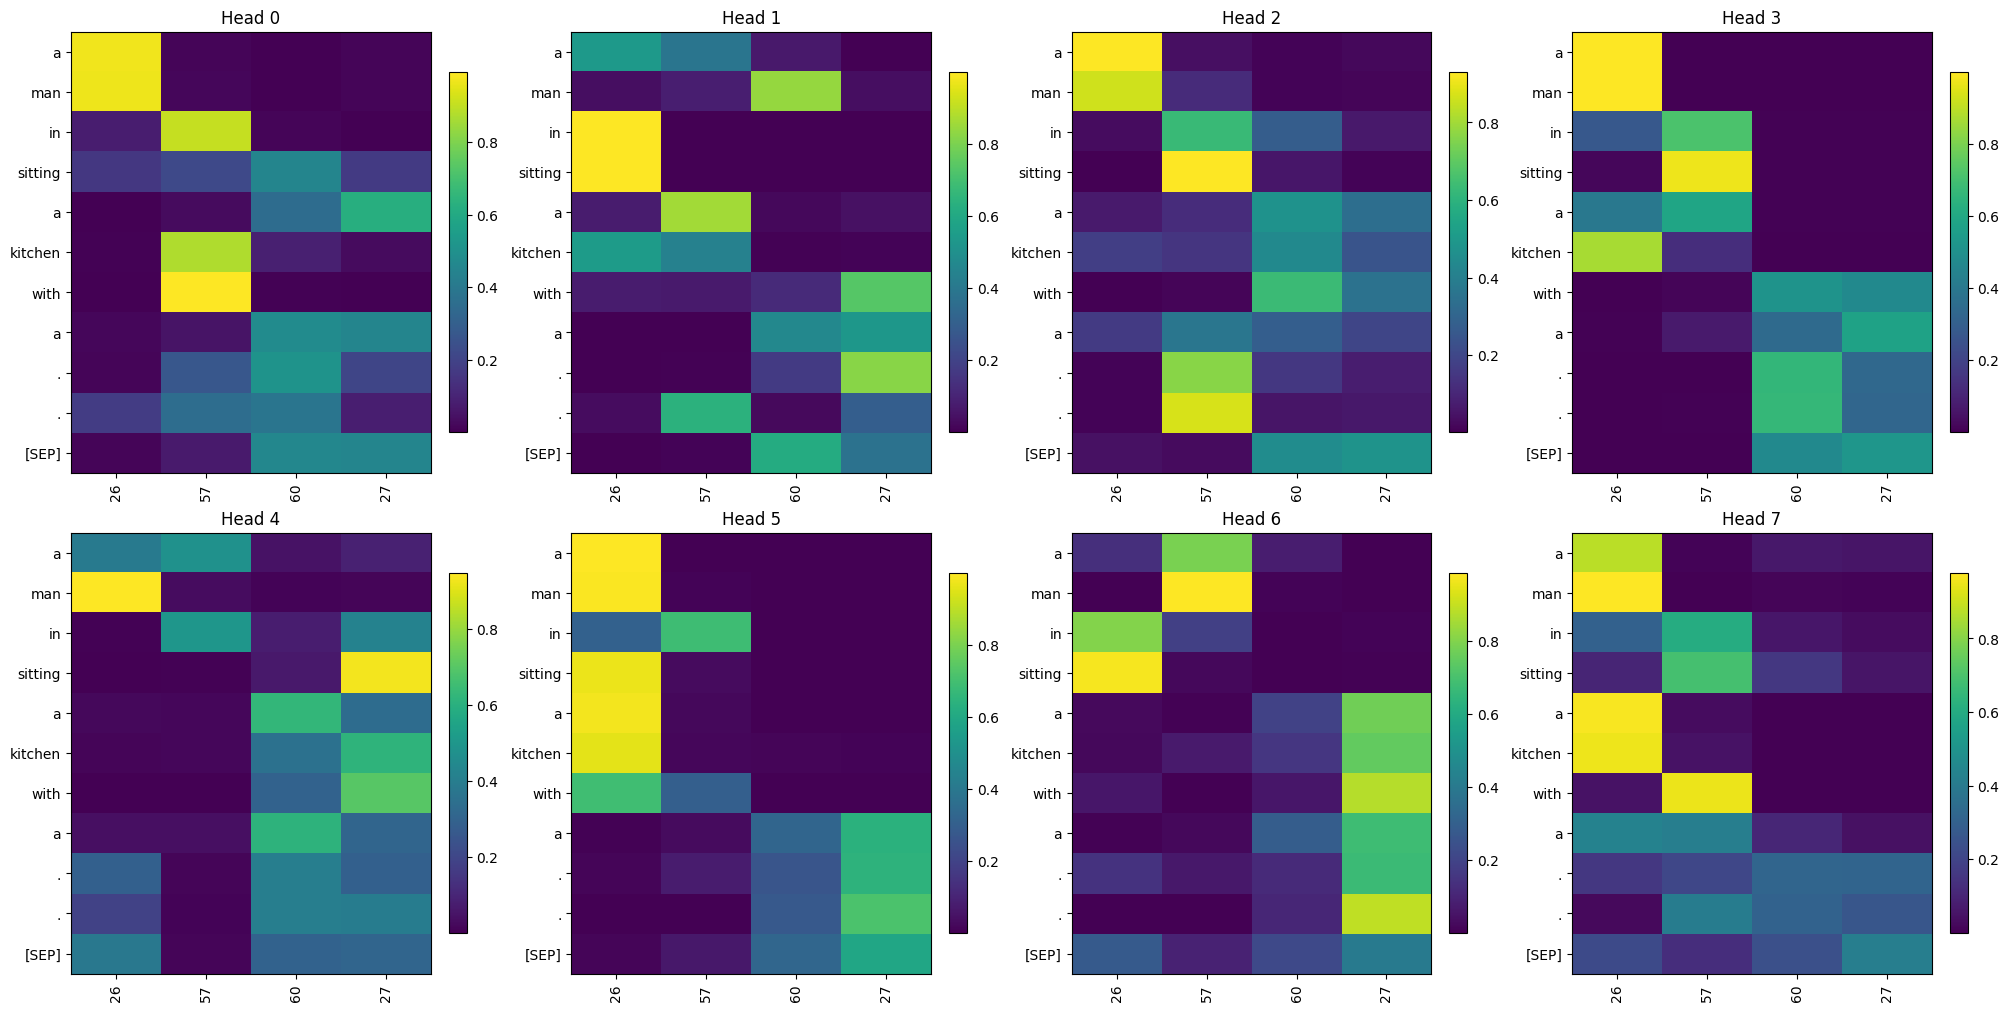

__


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Visualizing 8 attention heads
Attention shape: torch.Size([8, 15, 4])


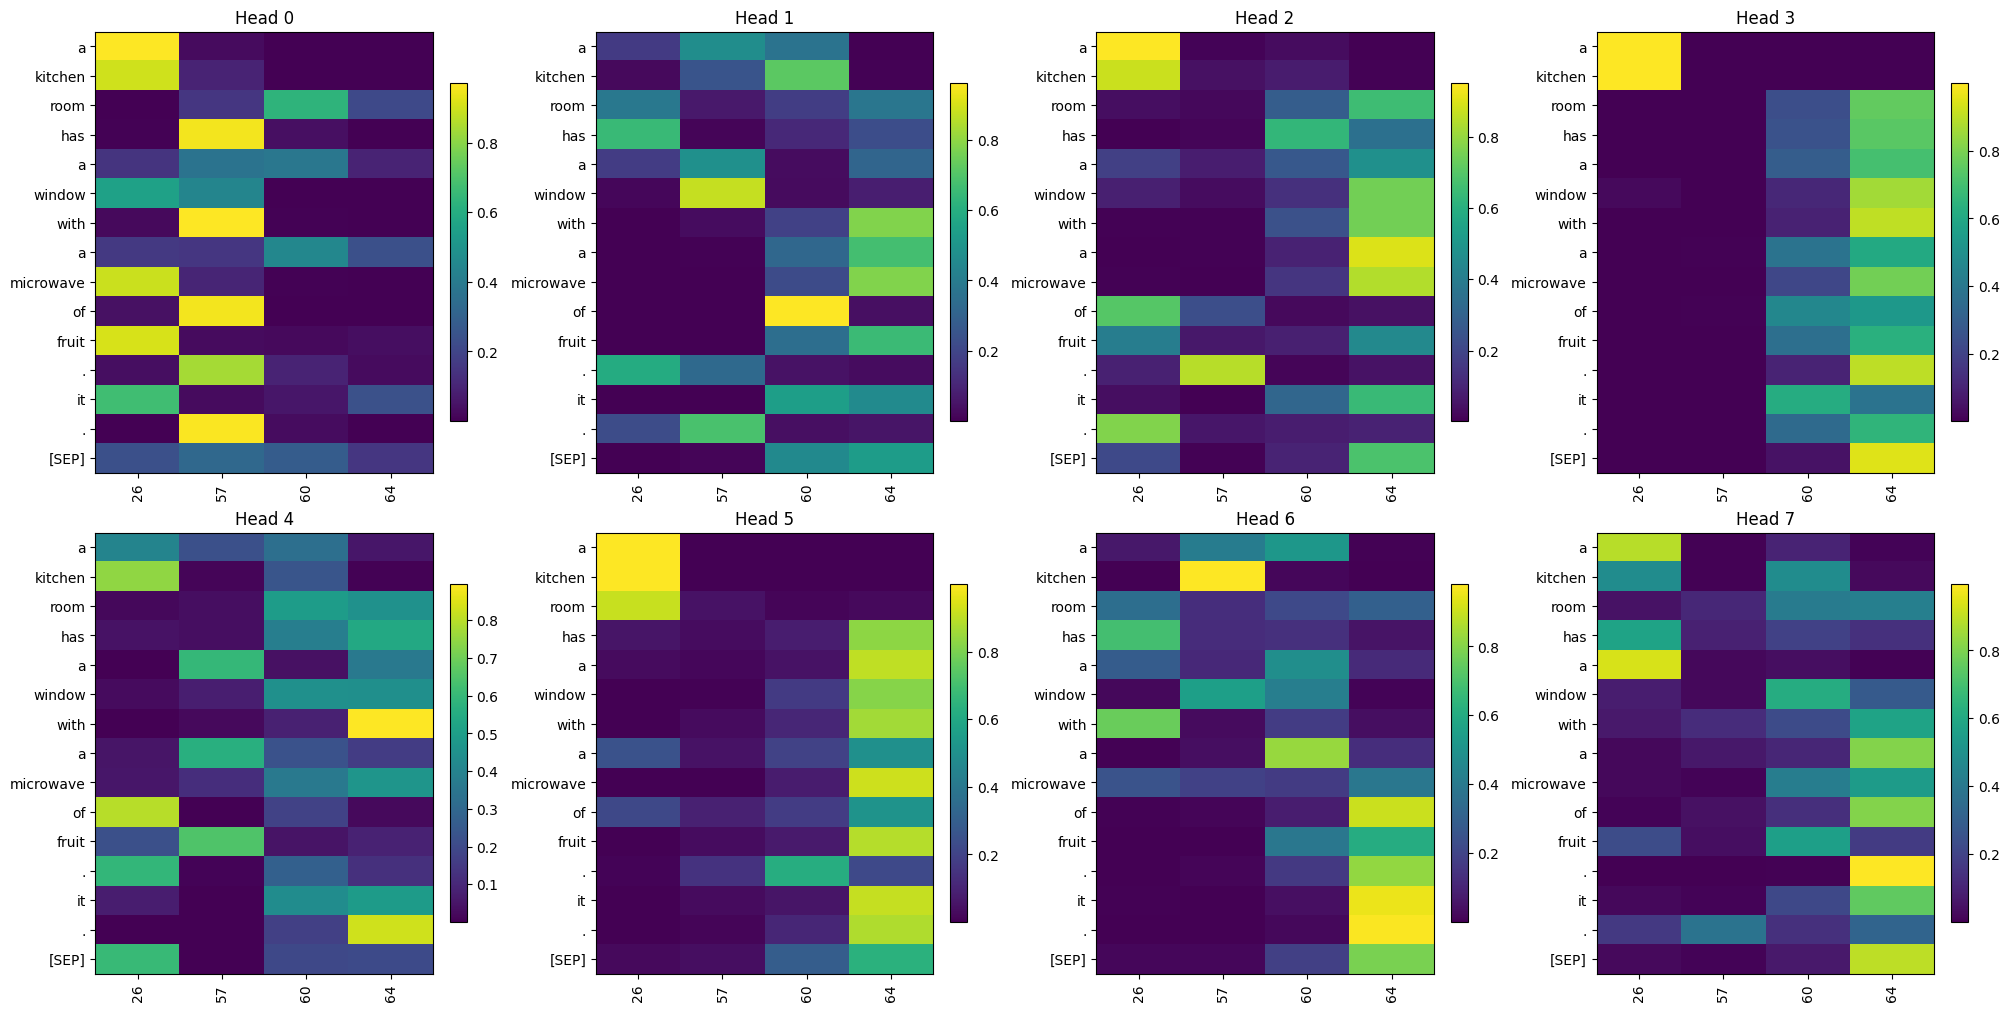

__


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Visualizing 8 attention heads
Attention shape: torch.Size([8, 11, 2])


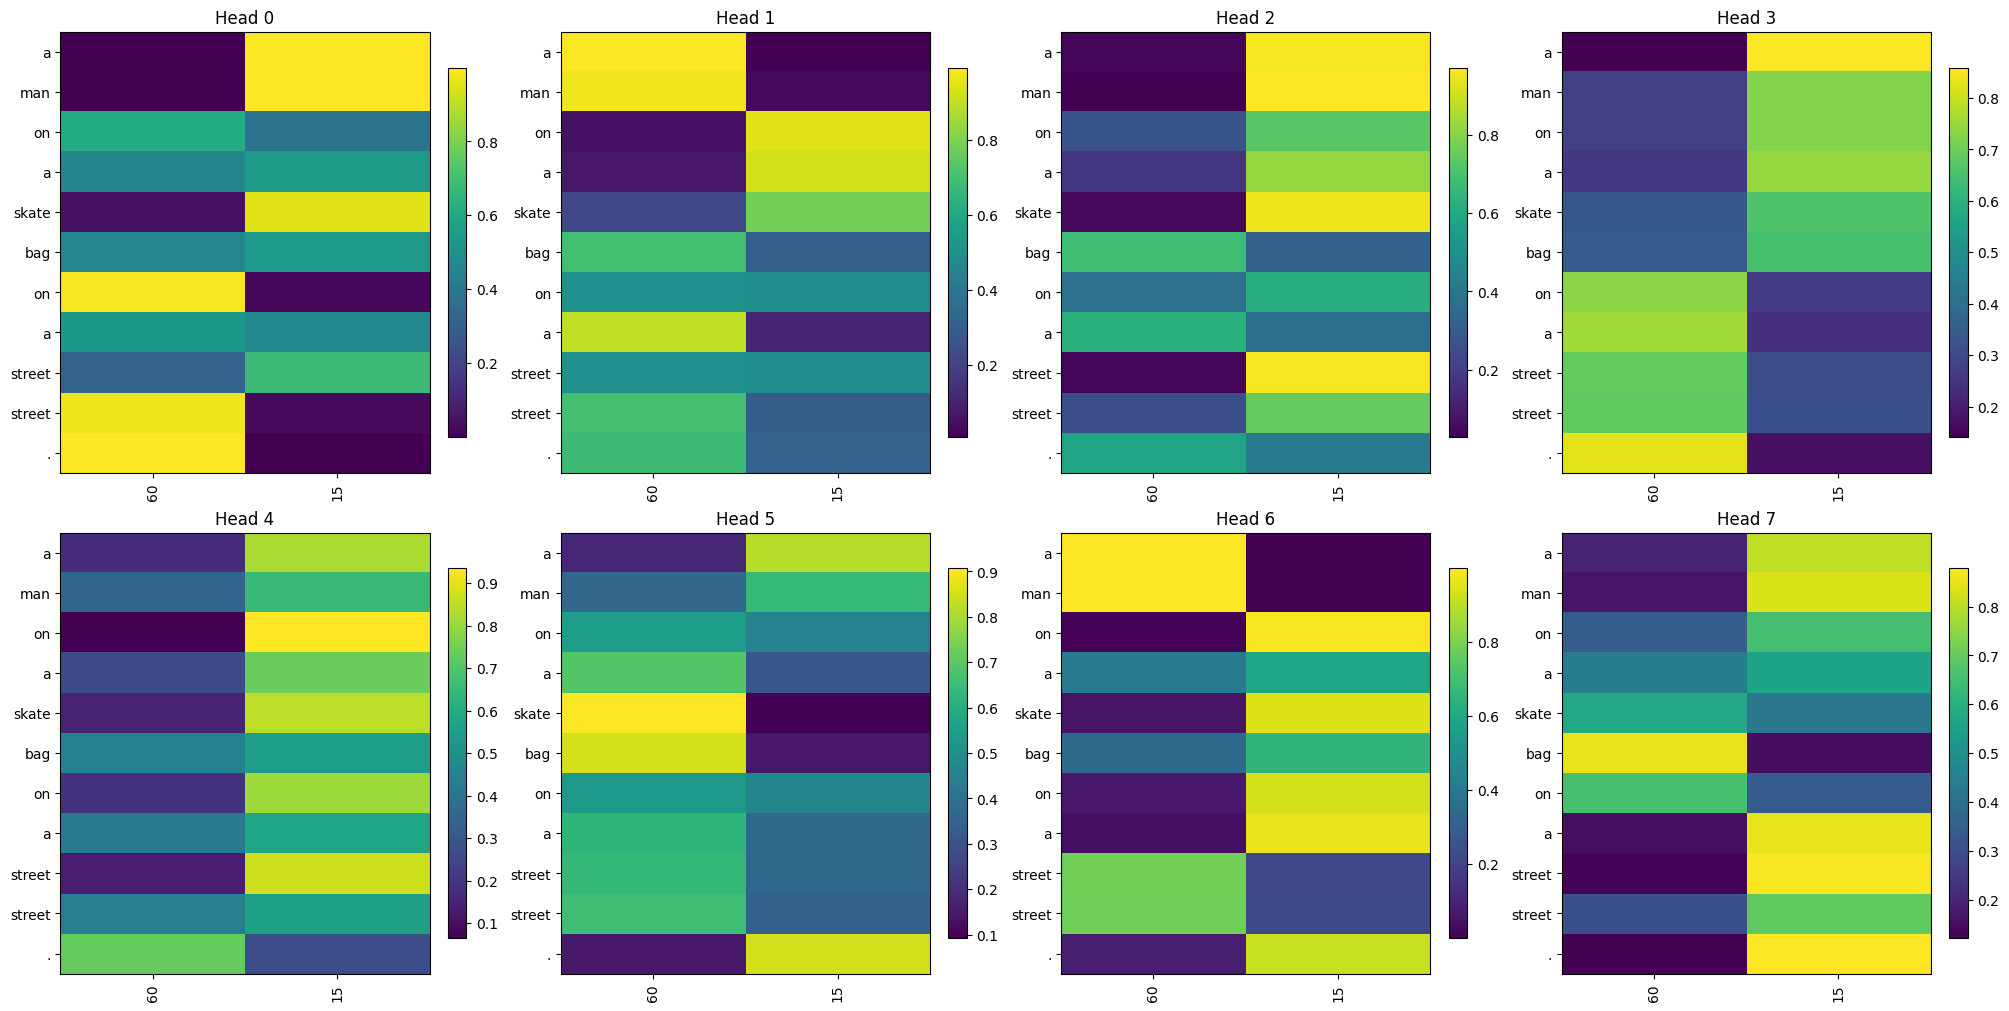

__


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Visualizing 8 attention heads
Attention shape: torch.Size([8, 14, 2])


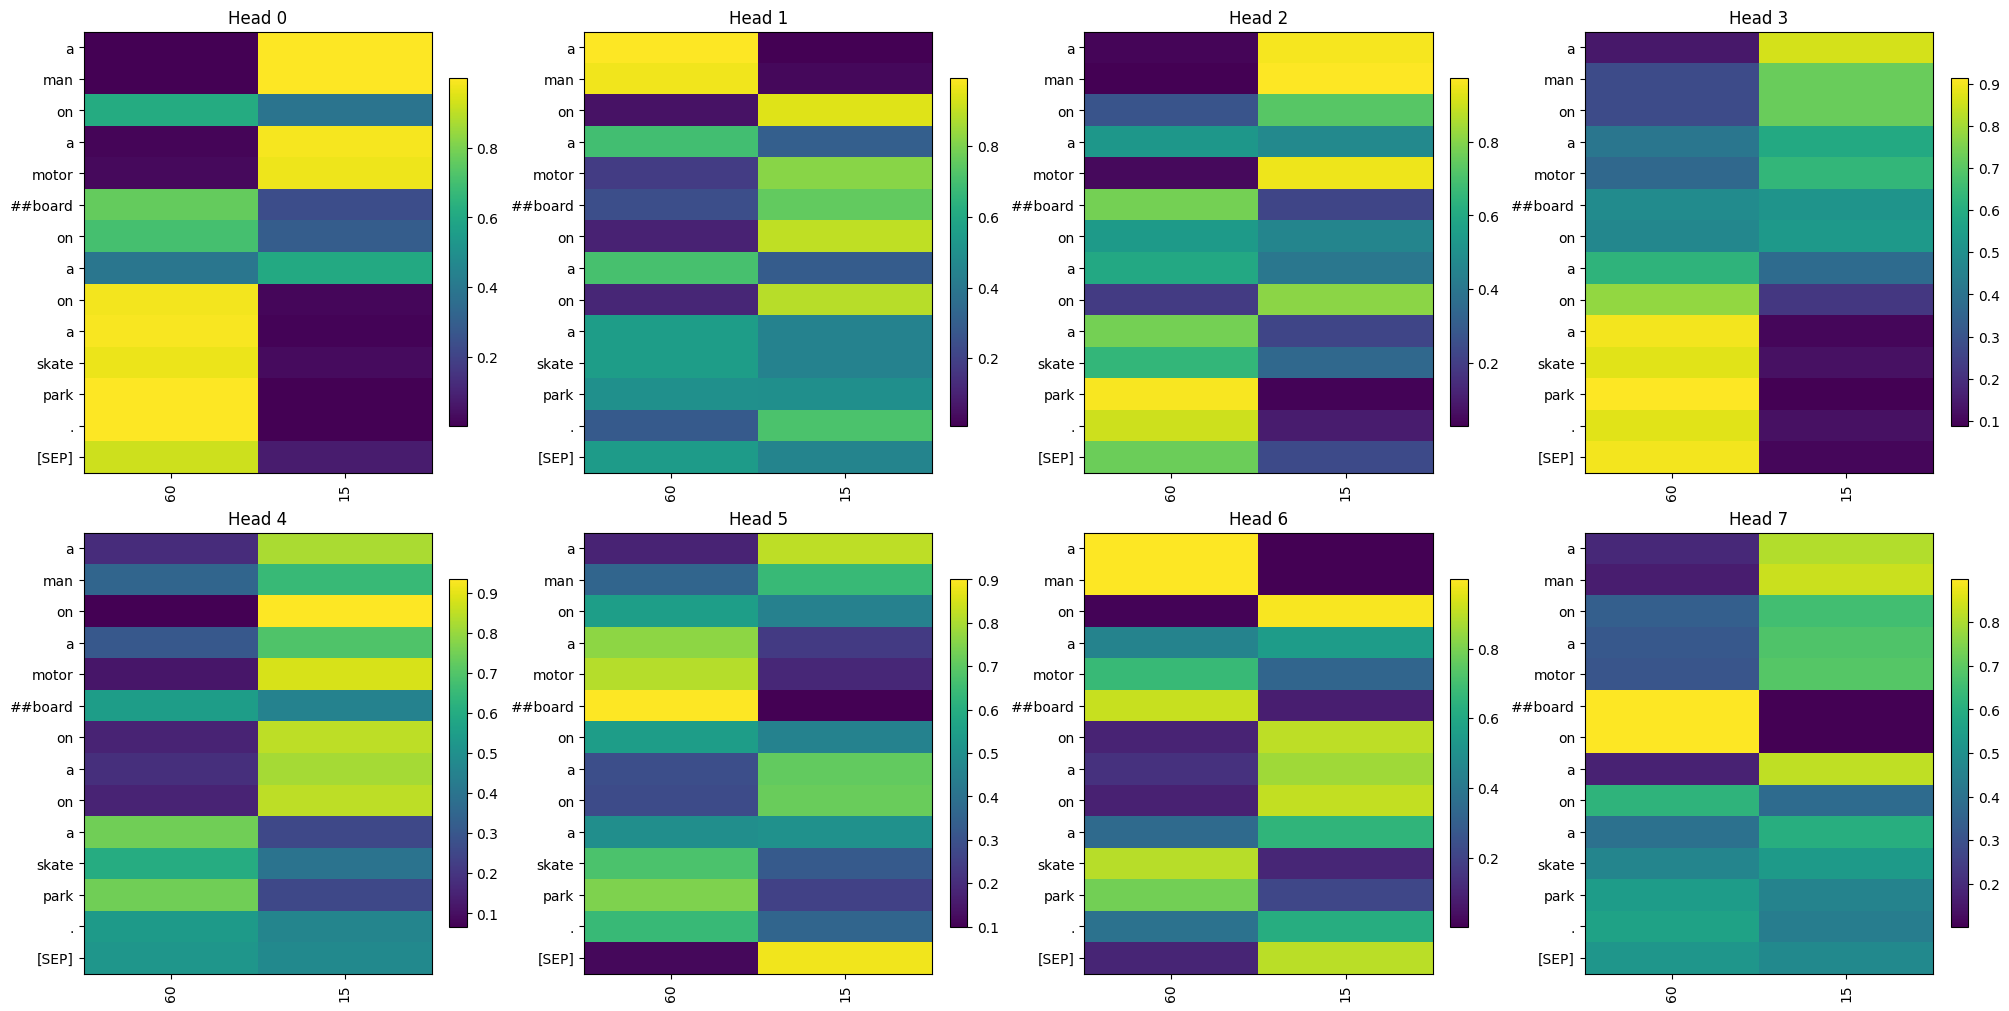

__


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Visualizing 8 attention heads
Attention shape: torch.Size([8, 9, 2])


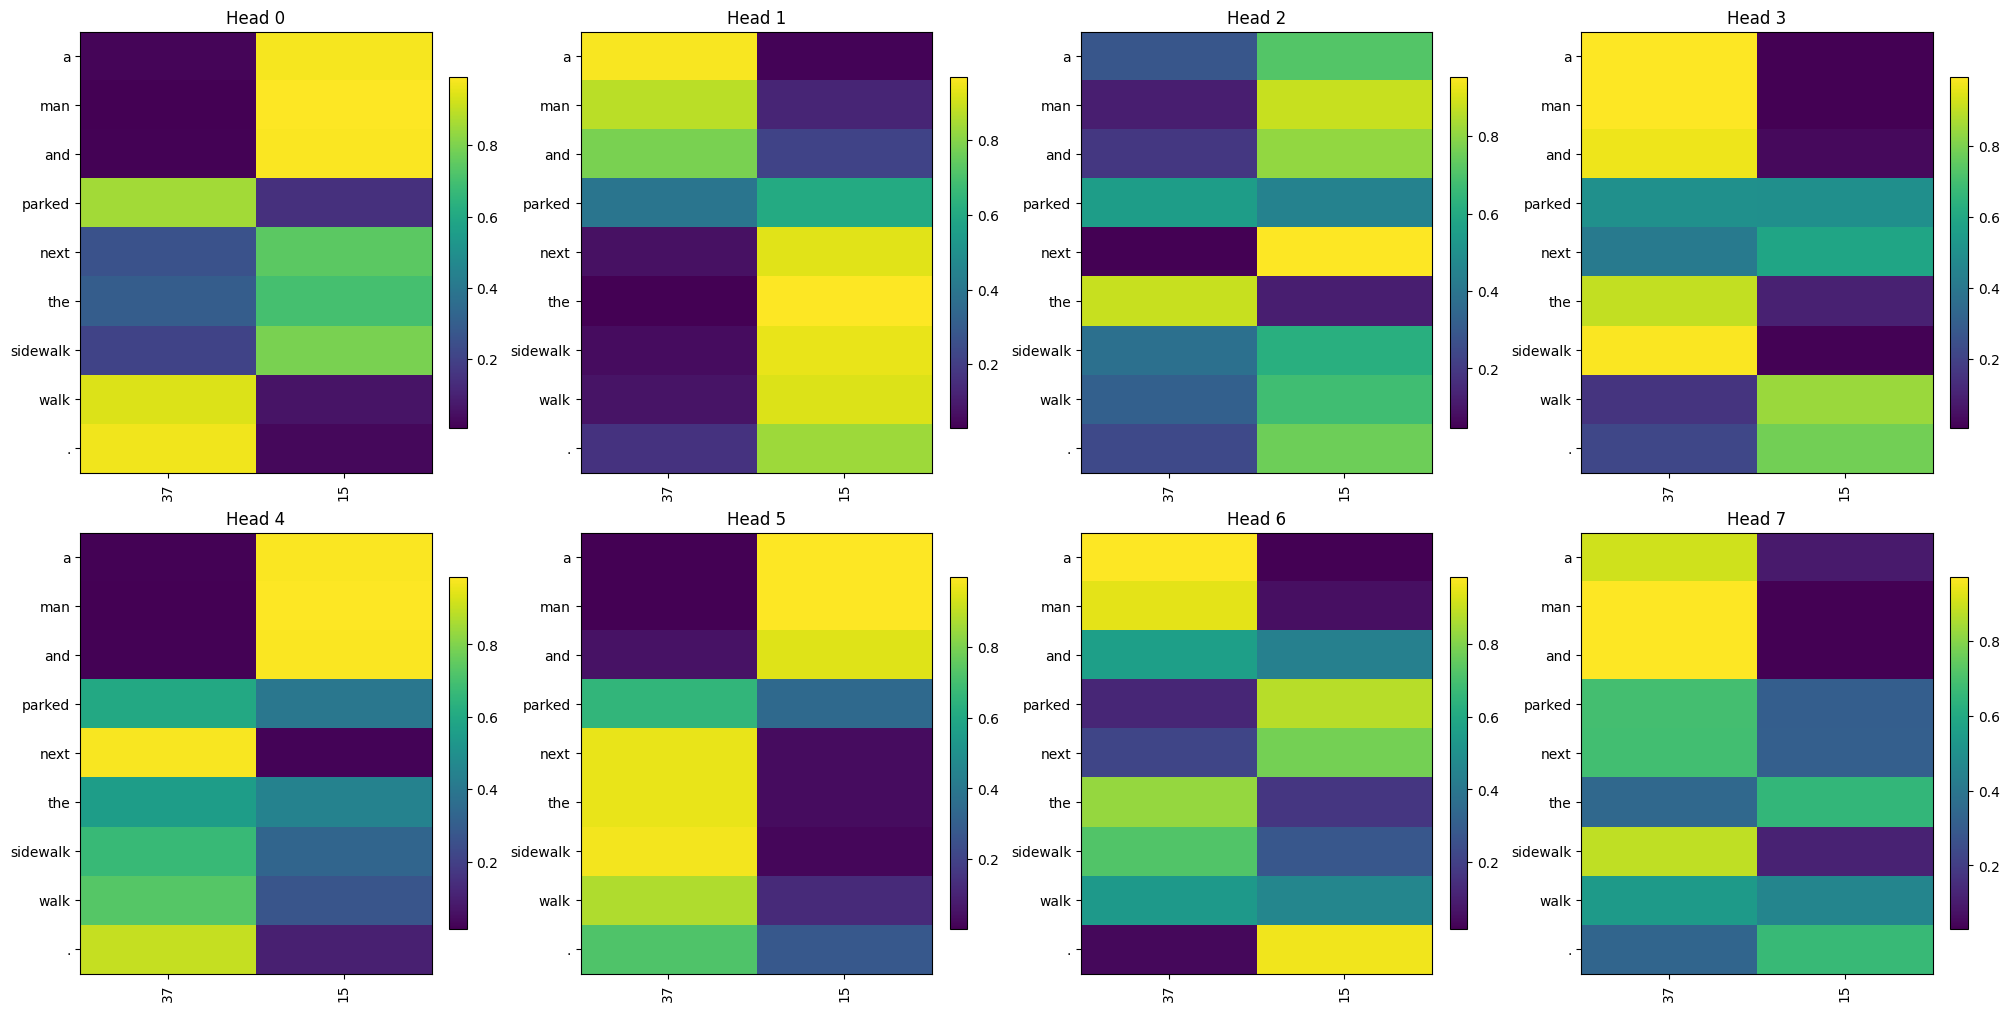

__


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Visualizing 8 attention heads
Attention shape: torch.Size([8, 12, 5])


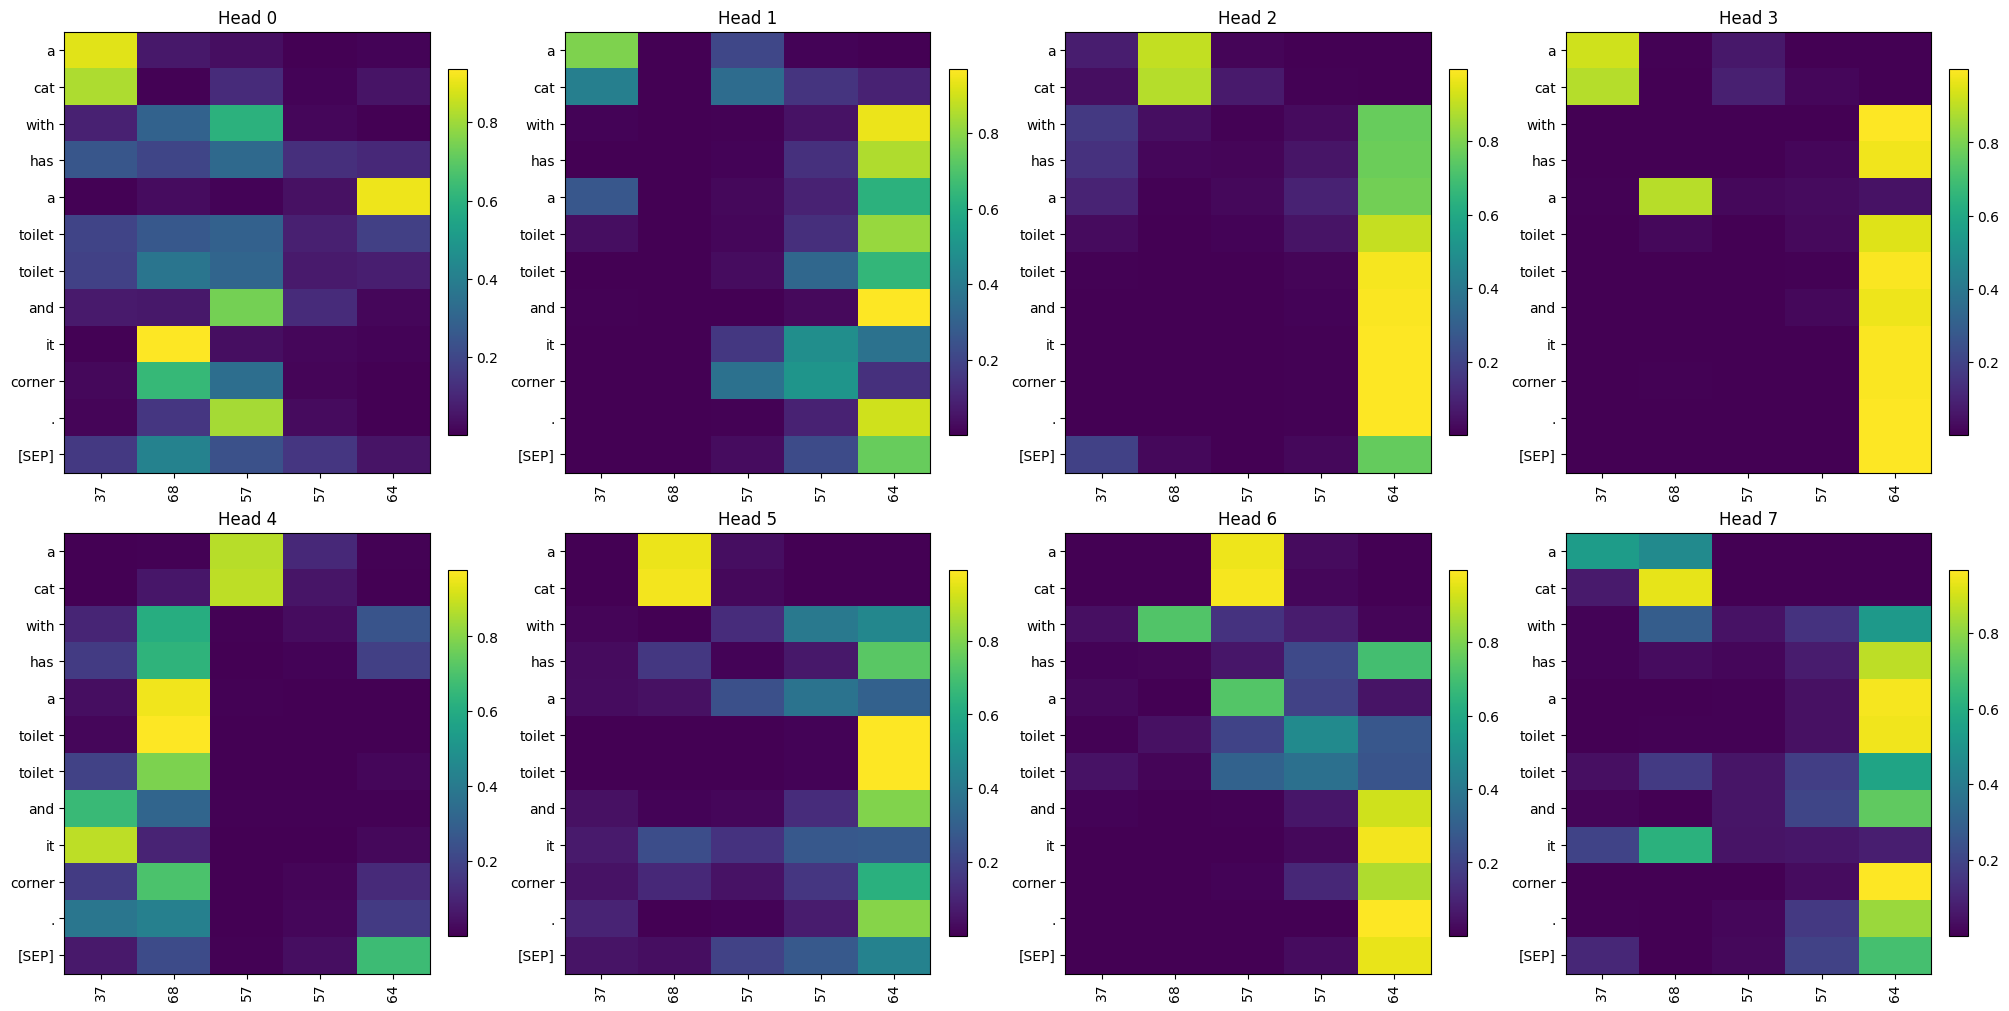

__


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Visualizing 8 attention heads
Attention shape: torch.Size([8, 10, 4])


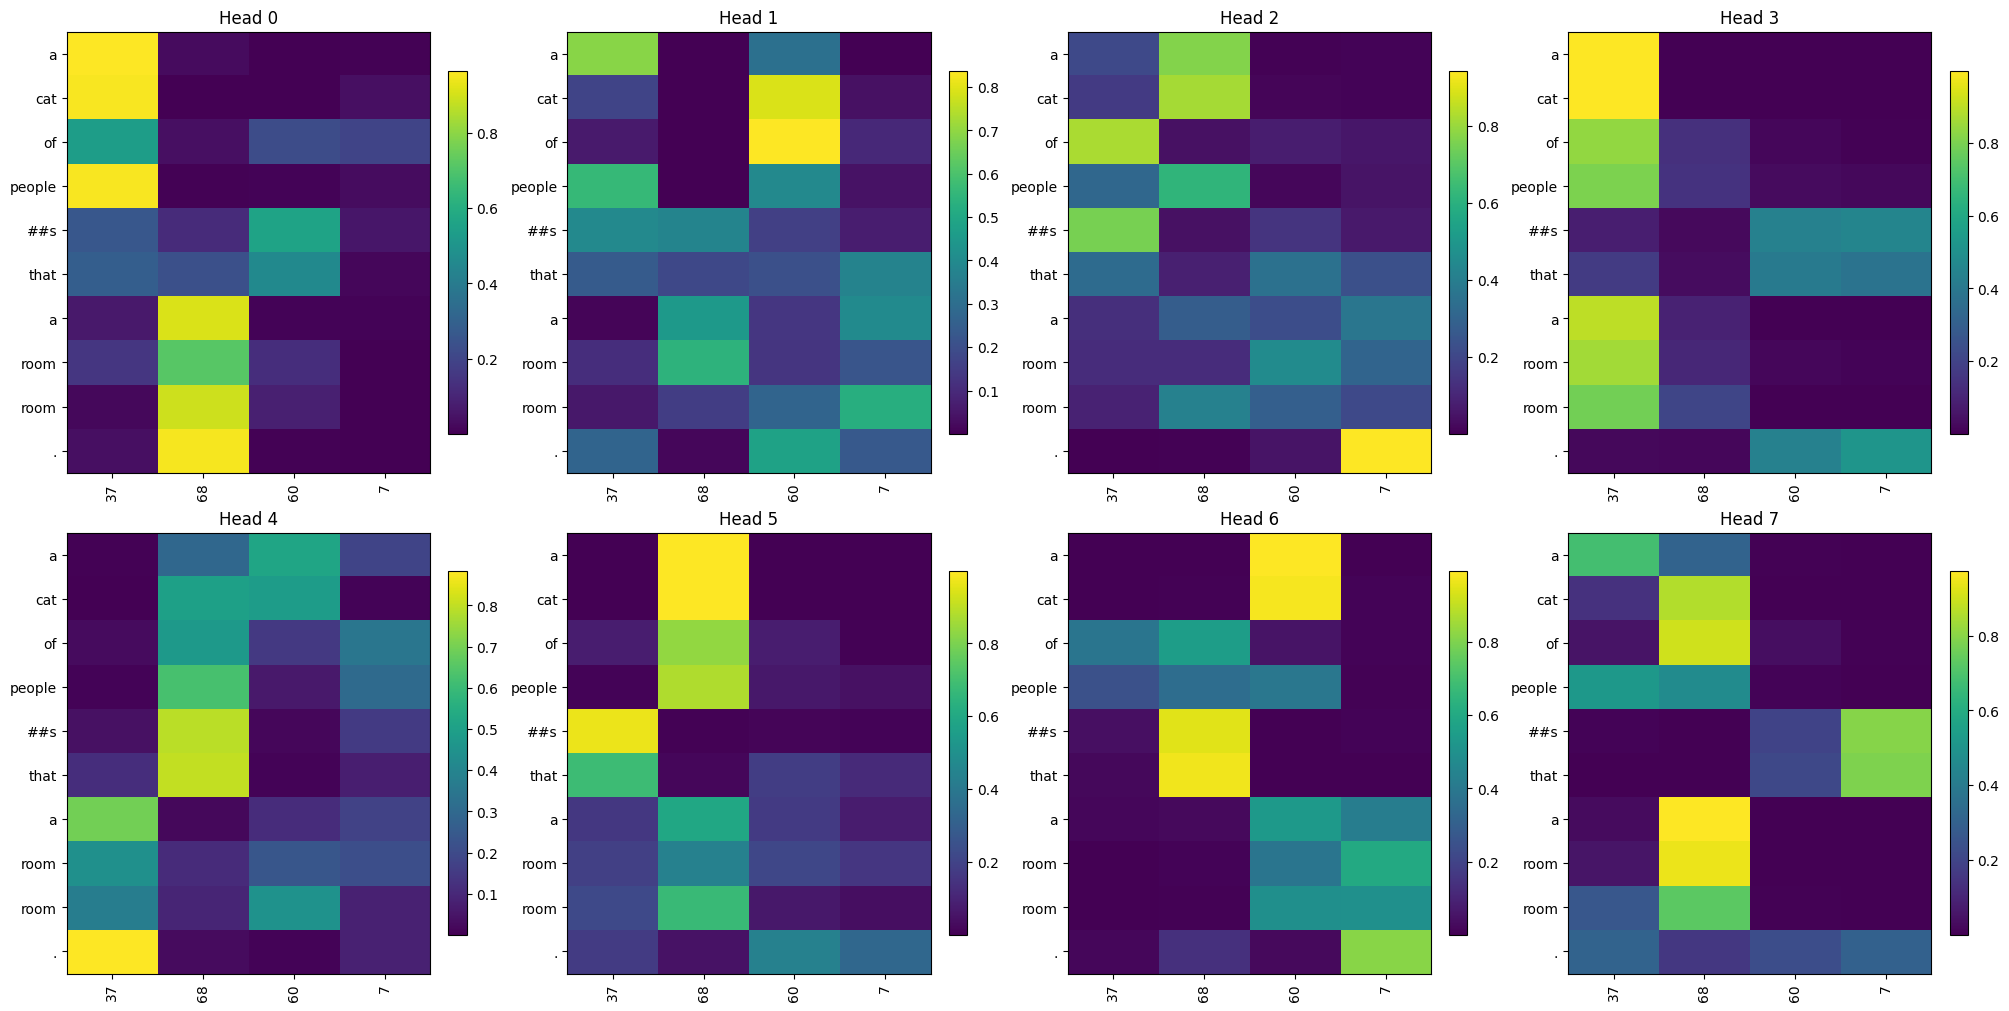

__


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Visualizing 8 attention heads
Attention shape: torch.Size([8, 10, 2])


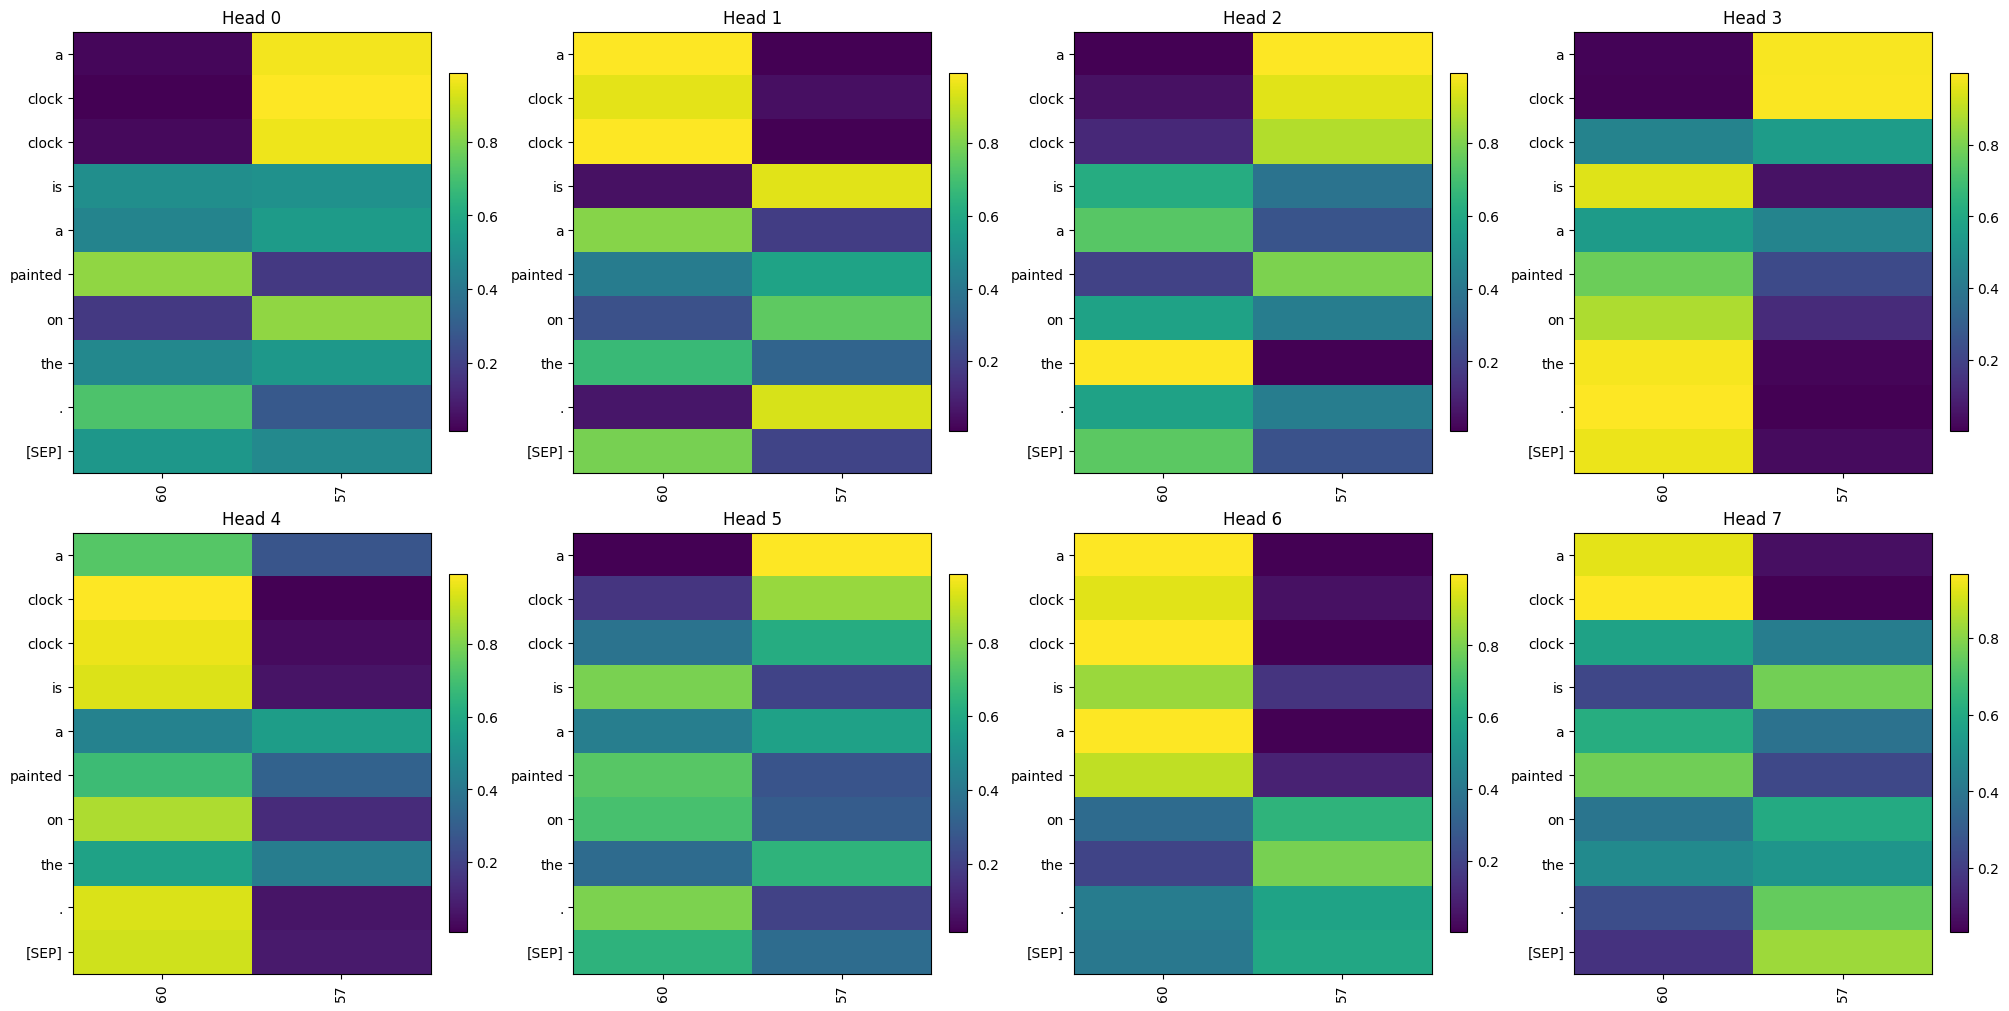

__


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Visualizing 8 attention heads
Attention shape: torch.Size([8, 14, 4])


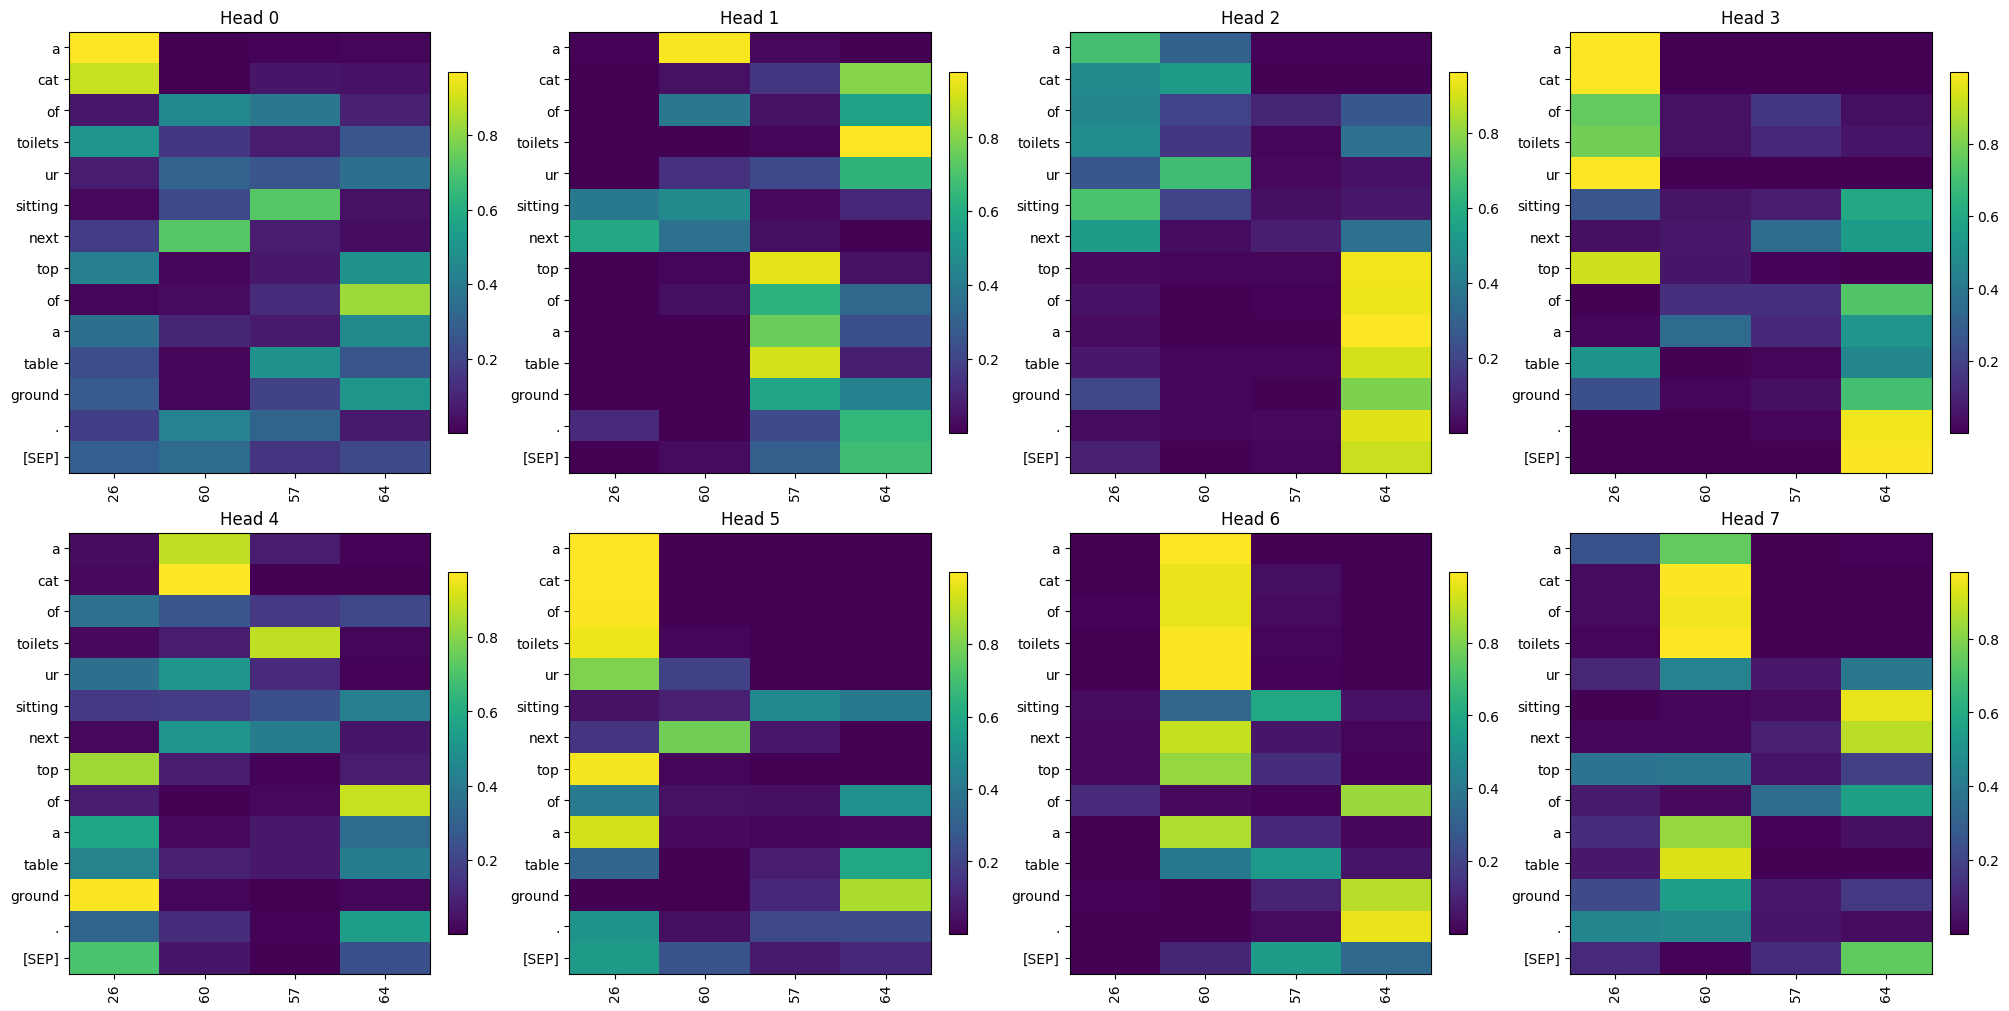

__


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Visualizing 8 attention heads
Attention shape: torch.Size([8, 10, 4])


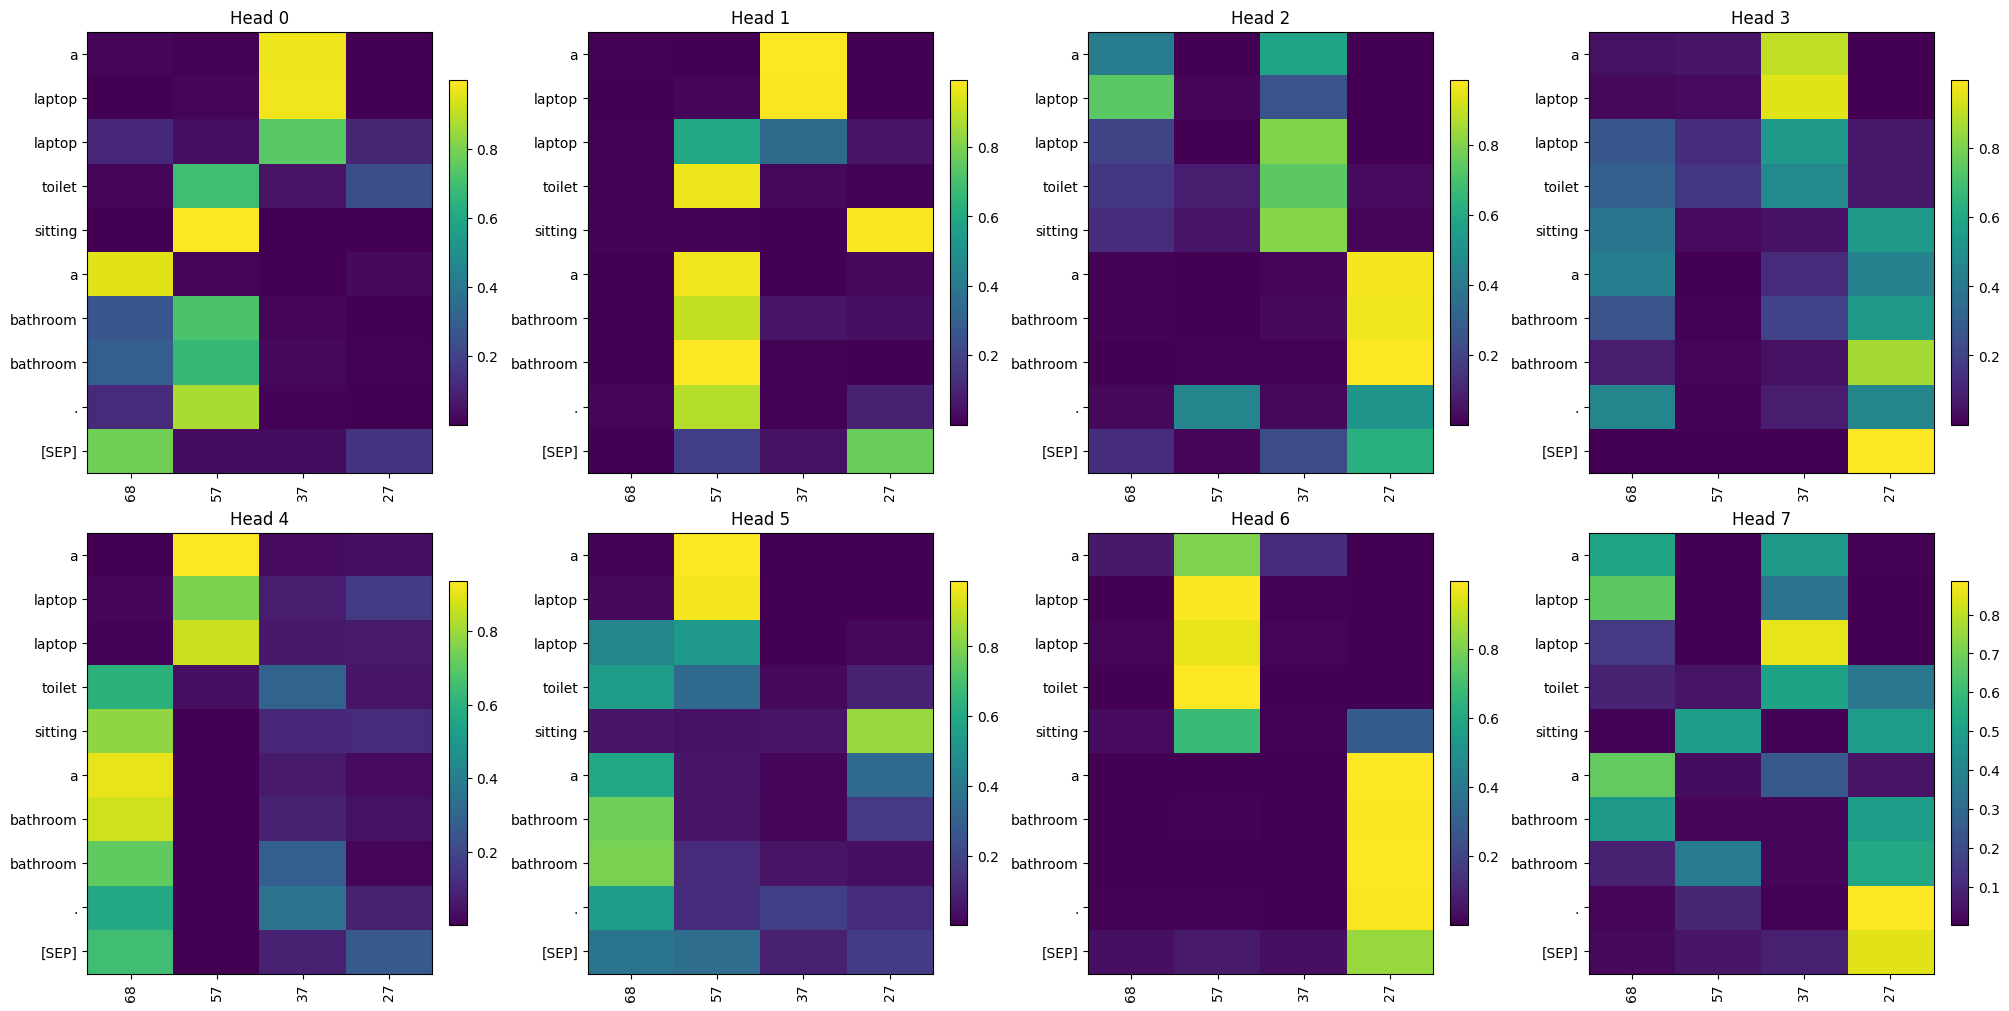

__


In [70]:
for i in range(10):
    decoder_attention(i)
    print('__')

In [72]:
import torch
import matplotlib.pyplot as plt
from datasets import load_from_disk
from transformers import AutoTokenizer
from translation import TransformerEncoder, TransformerDecoder

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def self_attention(sample_id):

    dataset = load_from_disk("/home/elena/emcomm/emcomm_captions/checkpoints/3_distractors_proper/messages/coco_val_message_captions_3_distractors")
    sample = dataset[sample_id]

    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

    src = torch.tensor(sample["message_truncated"]).unsqueeze(0).to(DEVICE)
    ref_text = sample["captions"][0]

    tgt = tokenizer(ref_text, return_tensors="pt")["input_ids"].to(DEVICE)

    encoder = TransformerEncoder(
        vocab_size=71,
        emb_dim=256,
        hid_dim=512,
        num_layers=2,
        pad_id=70,
        dropout=0.0,
        num_heads=8
    ).to(DEVICE)

    decoder = TransformerDecoder(
        vocab_size=len(tokenizer.vocab),
        emb_dim=256,
        hid_dim=512,
        num_layers=2,
        pad_id=tokenizer.pad_token_id,
        dropout=0.0,
        num_heads=8
    ).to(DEVICE)

    checkpoint = torch.load("/home/elena/emcomm/emcomm_captions/checkpoints/3_distractors_proper/translation/checkpoint.pt", map_location=DEVICE)

    encoder.load_state_dict(checkpoint["encoder"])
    decoder.load_state_dict(checkpoint["decoder"])

    encoder.to(DEVICE).eval()
    decoder.to(DEVICE).eval()
    # decoder.transformer.layers[-1].multihead_attn.need_weights = True

    # ---------------- hook ----------------
    attention = {}

    layer = encoder.transformer.layers[-1].self_attn
    orig_forward = layer.forward

    def new_forward(*args, **kwargs):
        kwargs["need_weights"] = True
        kwargs["average_attn_weights"] = False
        out = orig_forward(*args, **kwargs)
        attention["weights"] = out[1].detach()
        return out

    layer.forward = new_forward

    def hook(module, input, output):
        attention["weights"] = output[1].detach()

    encoder.transformer.layers[-1].self_attn.register_forward_hook(hook)
    # --------------------------------------
    
    with torch.no_grad():

        memory, _ = encoder(src)

        logits, _, _ = decoder(tgt[:, :-1], memory)

        pred = logits.argmax(-1)

    attn = attention["weights"][0]  # remove batch

    hyp_tokens = tokenizer.convert_ids_to_tokens(pred[0])
    src_tokens = [str(t.item()) for t in src[0]]

    visualize_attention(attn, hyp_tokens, src_tokens)#, heads=1)


# if __name__ == "__main__":


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Visualizing 8 attention heads
Attention shape: torch.Size([8, 8, 8])


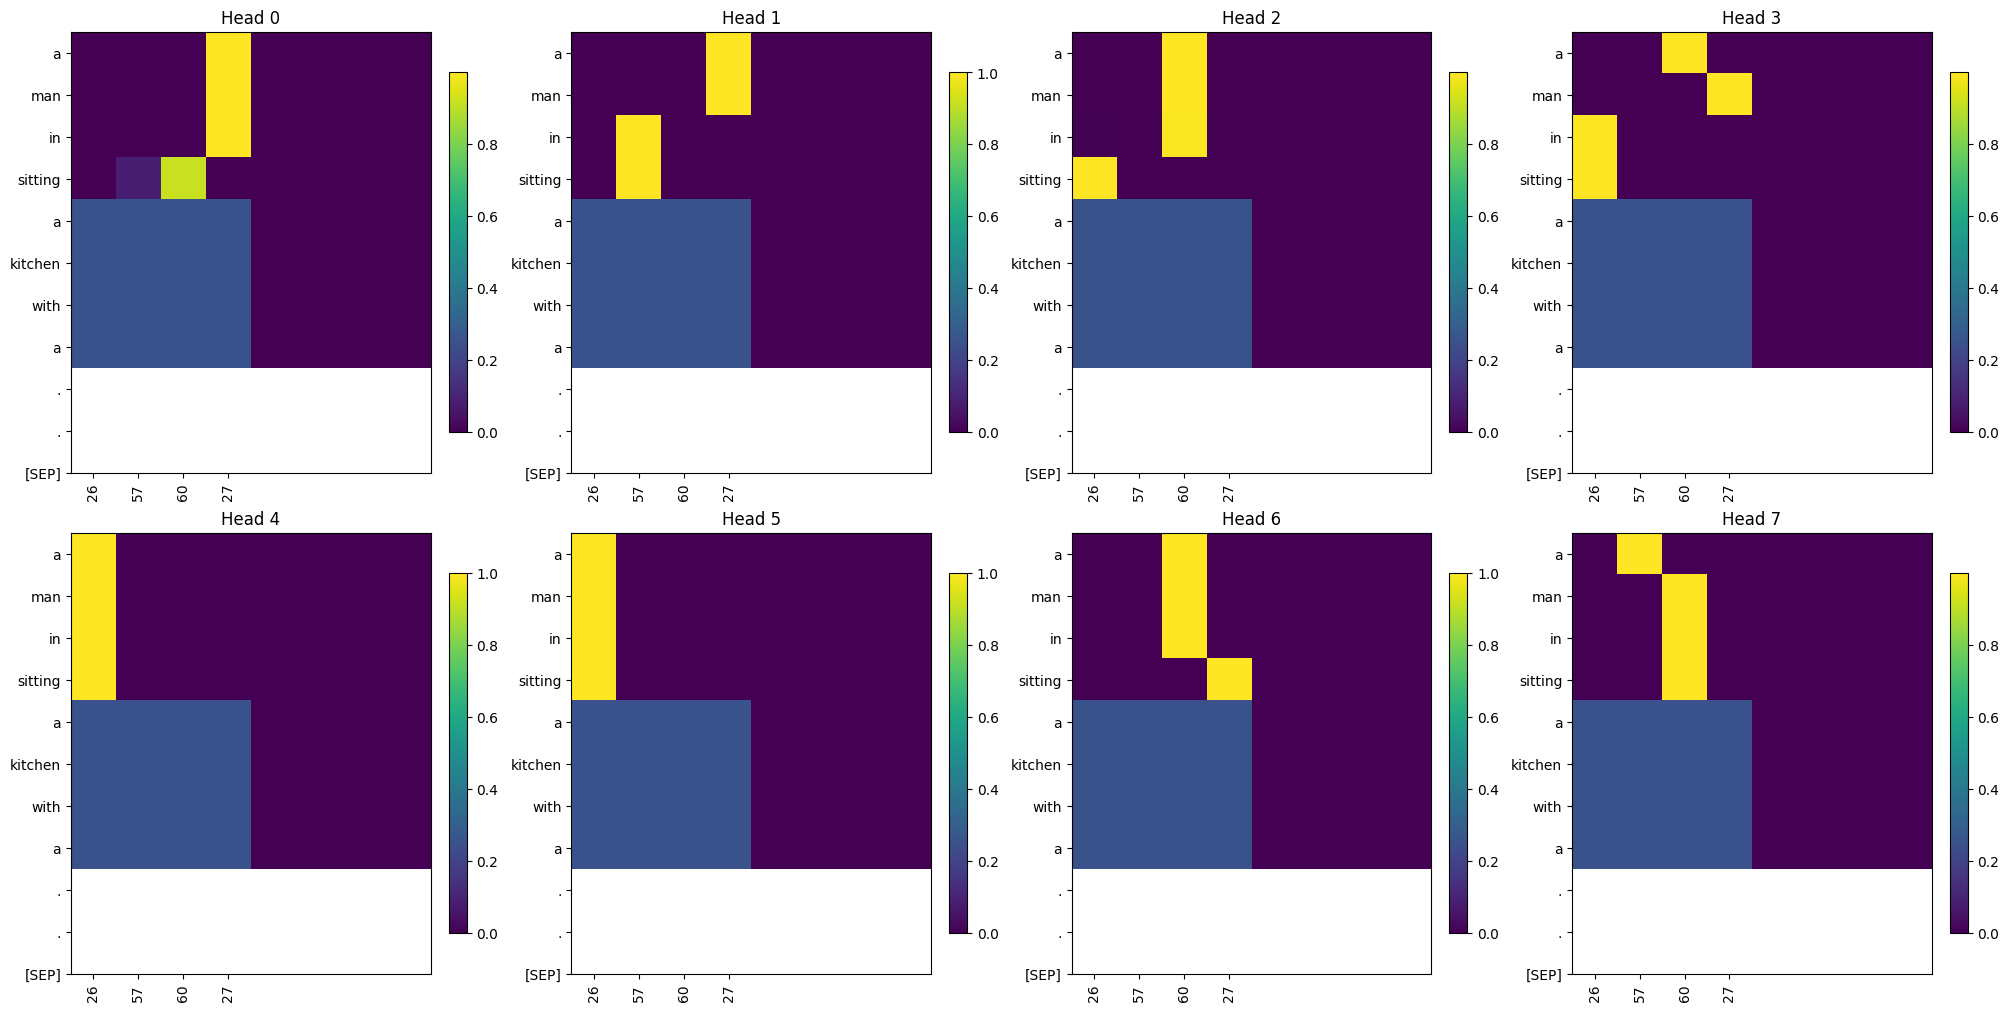

__


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Visualizing 8 attention heads
Attention shape: torch.Size([8, 8, 8])


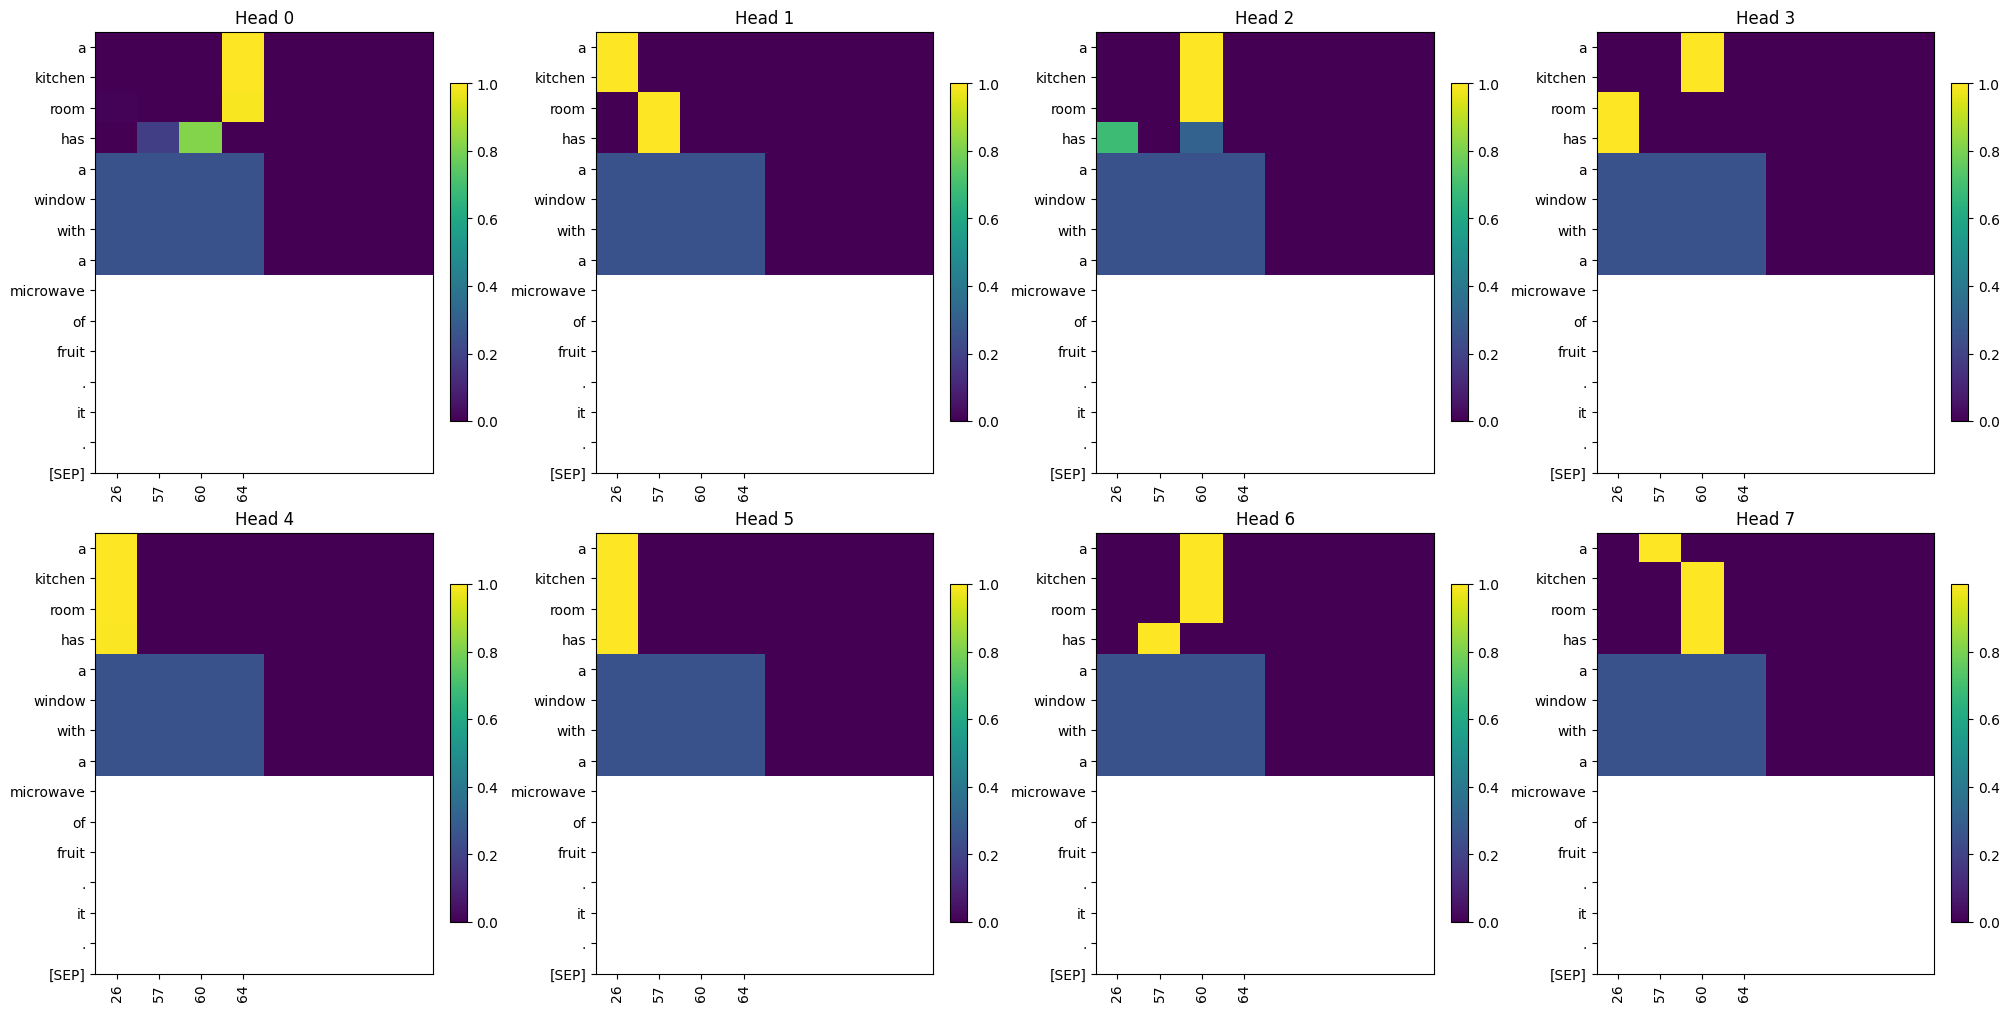

__


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Visualizing 8 attention heads
Attention shape: torch.Size([8, 8, 8])


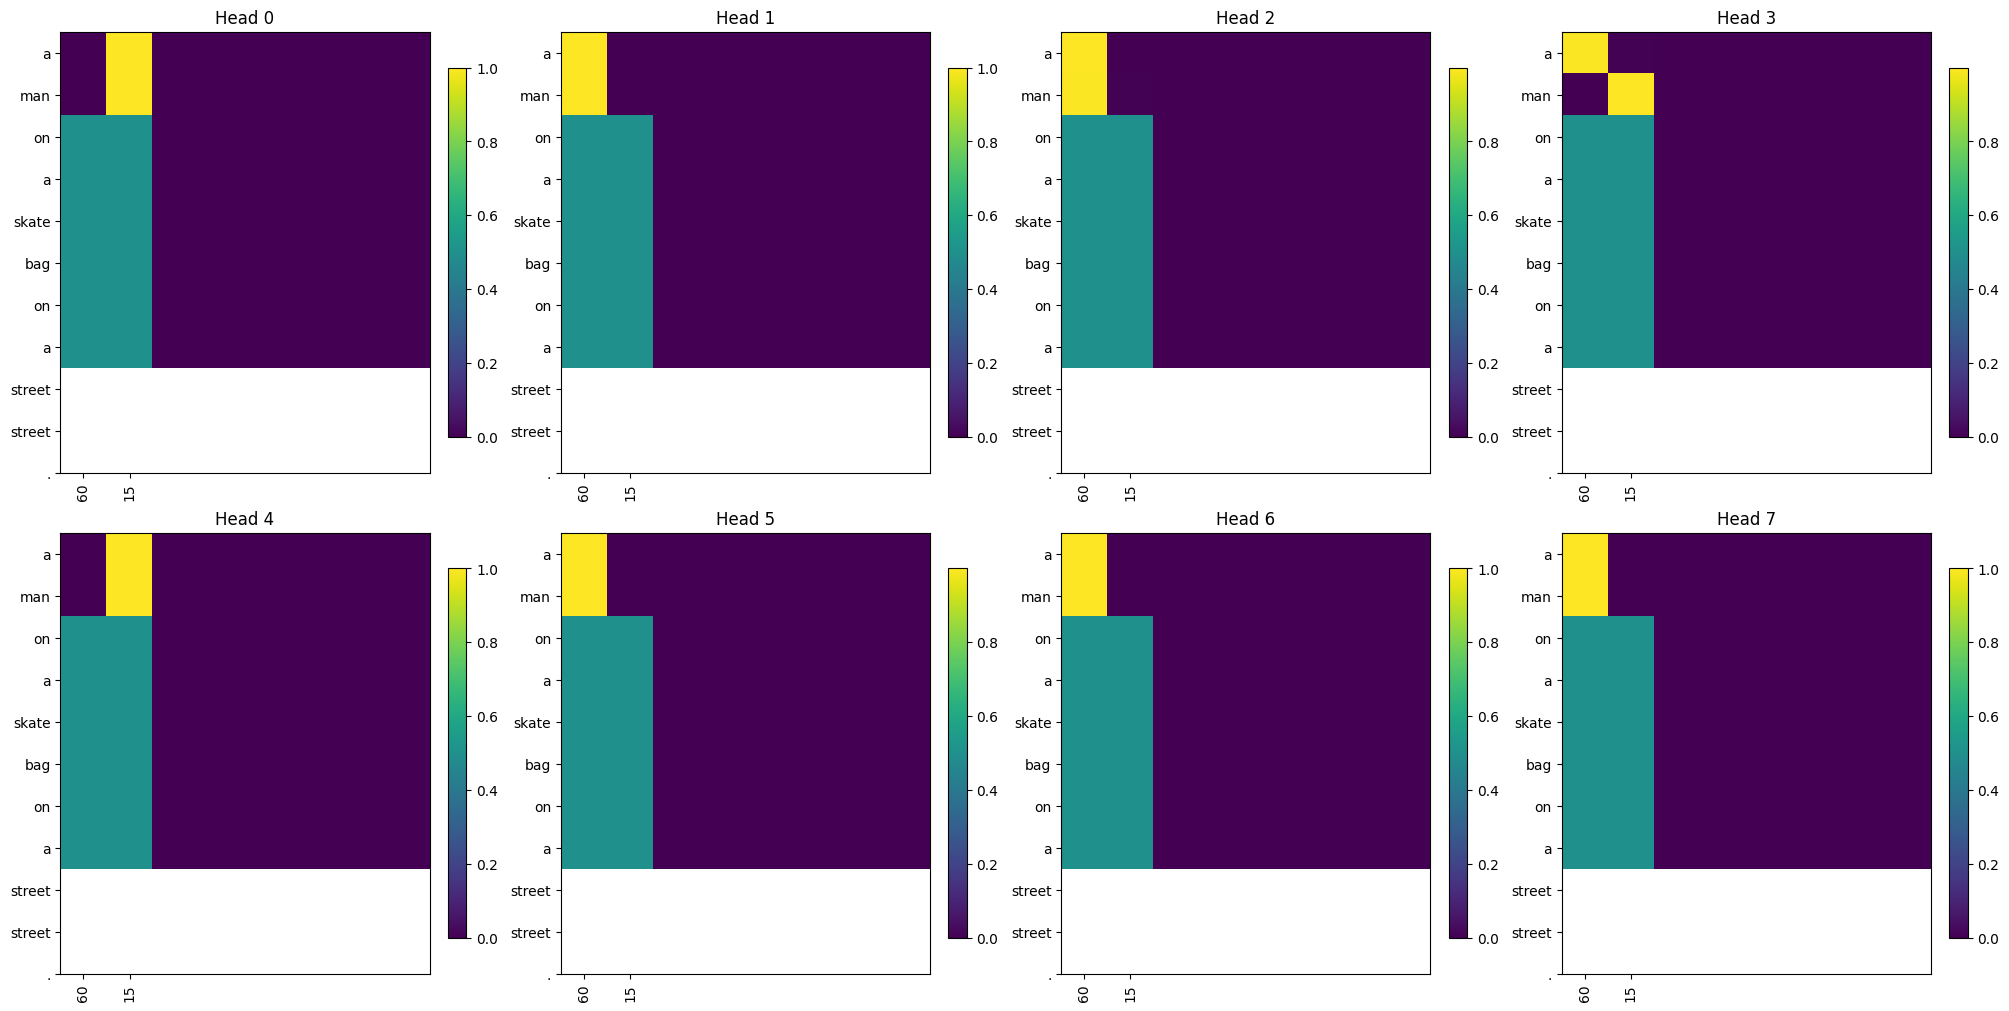

__


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Visualizing 8 attention heads
Attention shape: torch.Size([8, 8, 8])


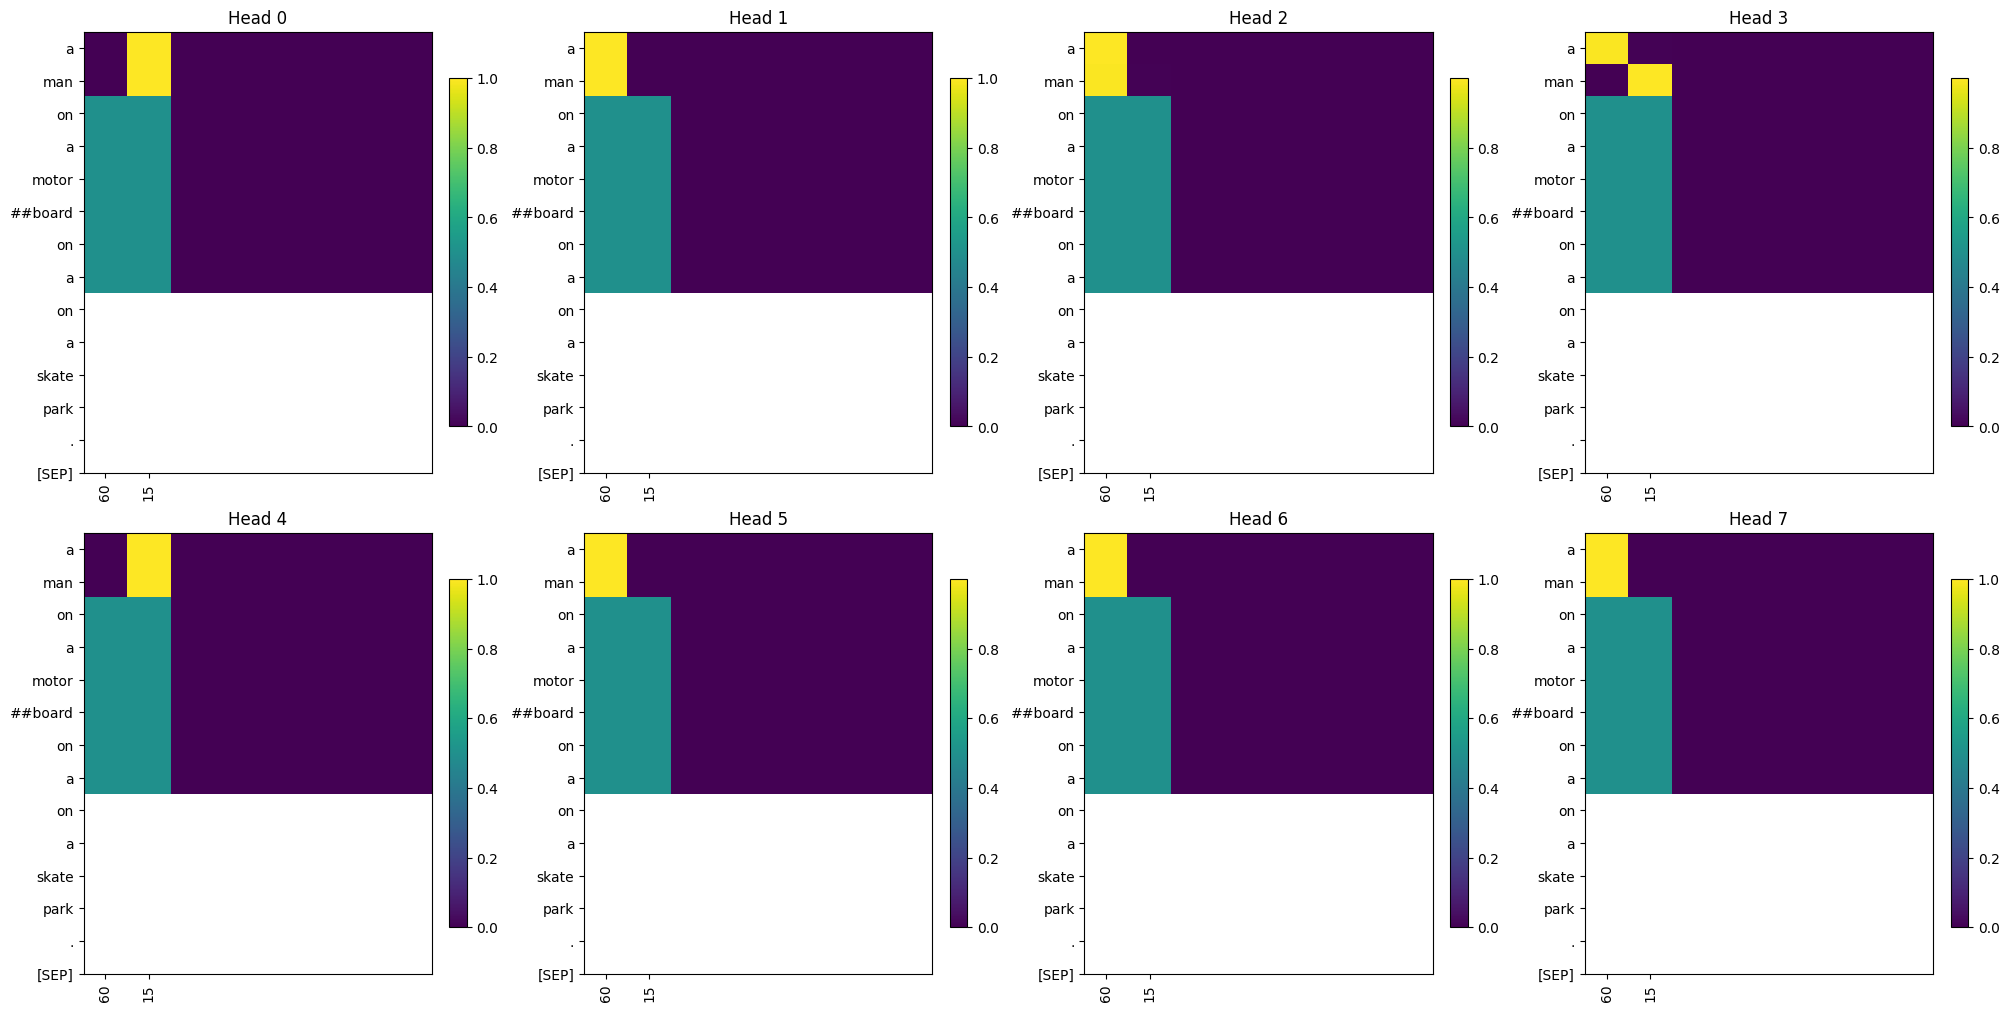

__


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Visualizing 8 attention heads
Attention shape: torch.Size([8, 8, 8])


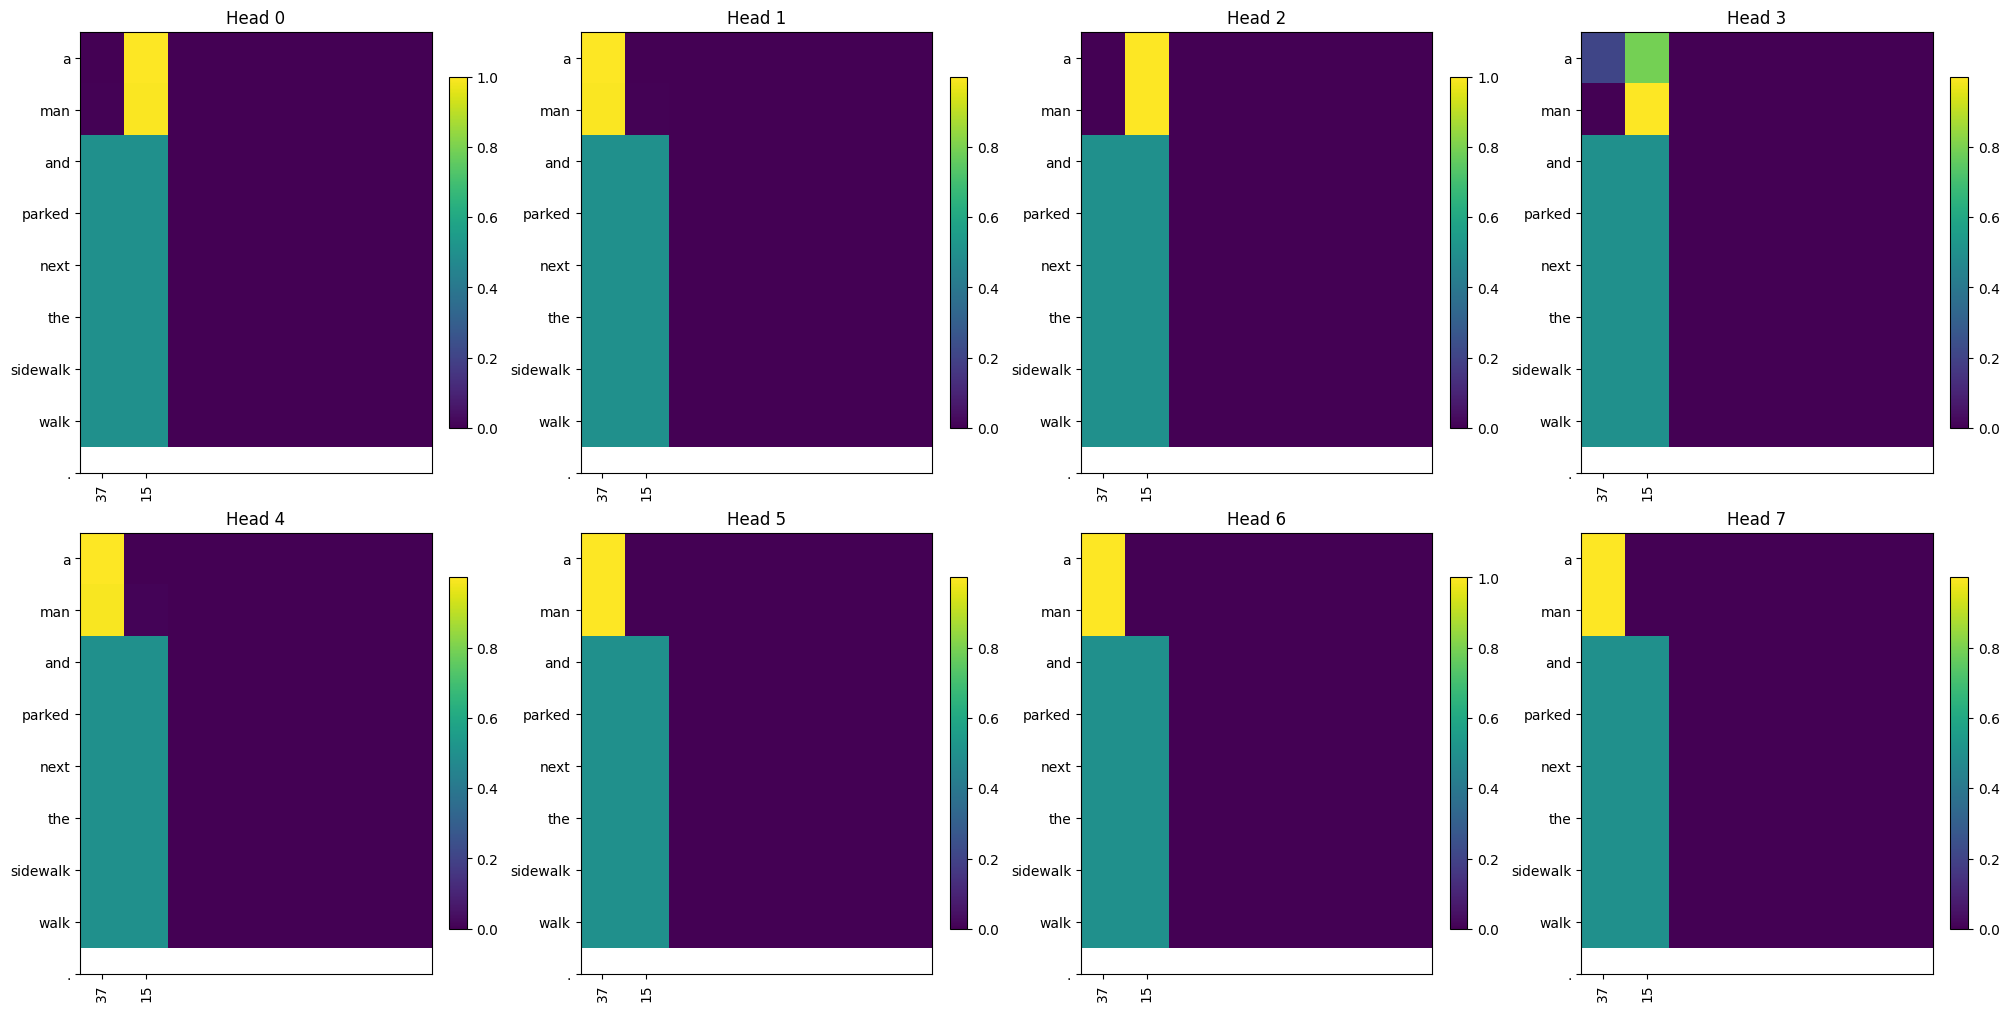

__


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Visualizing 8 attention heads
Attention shape: torch.Size([8, 8, 8])


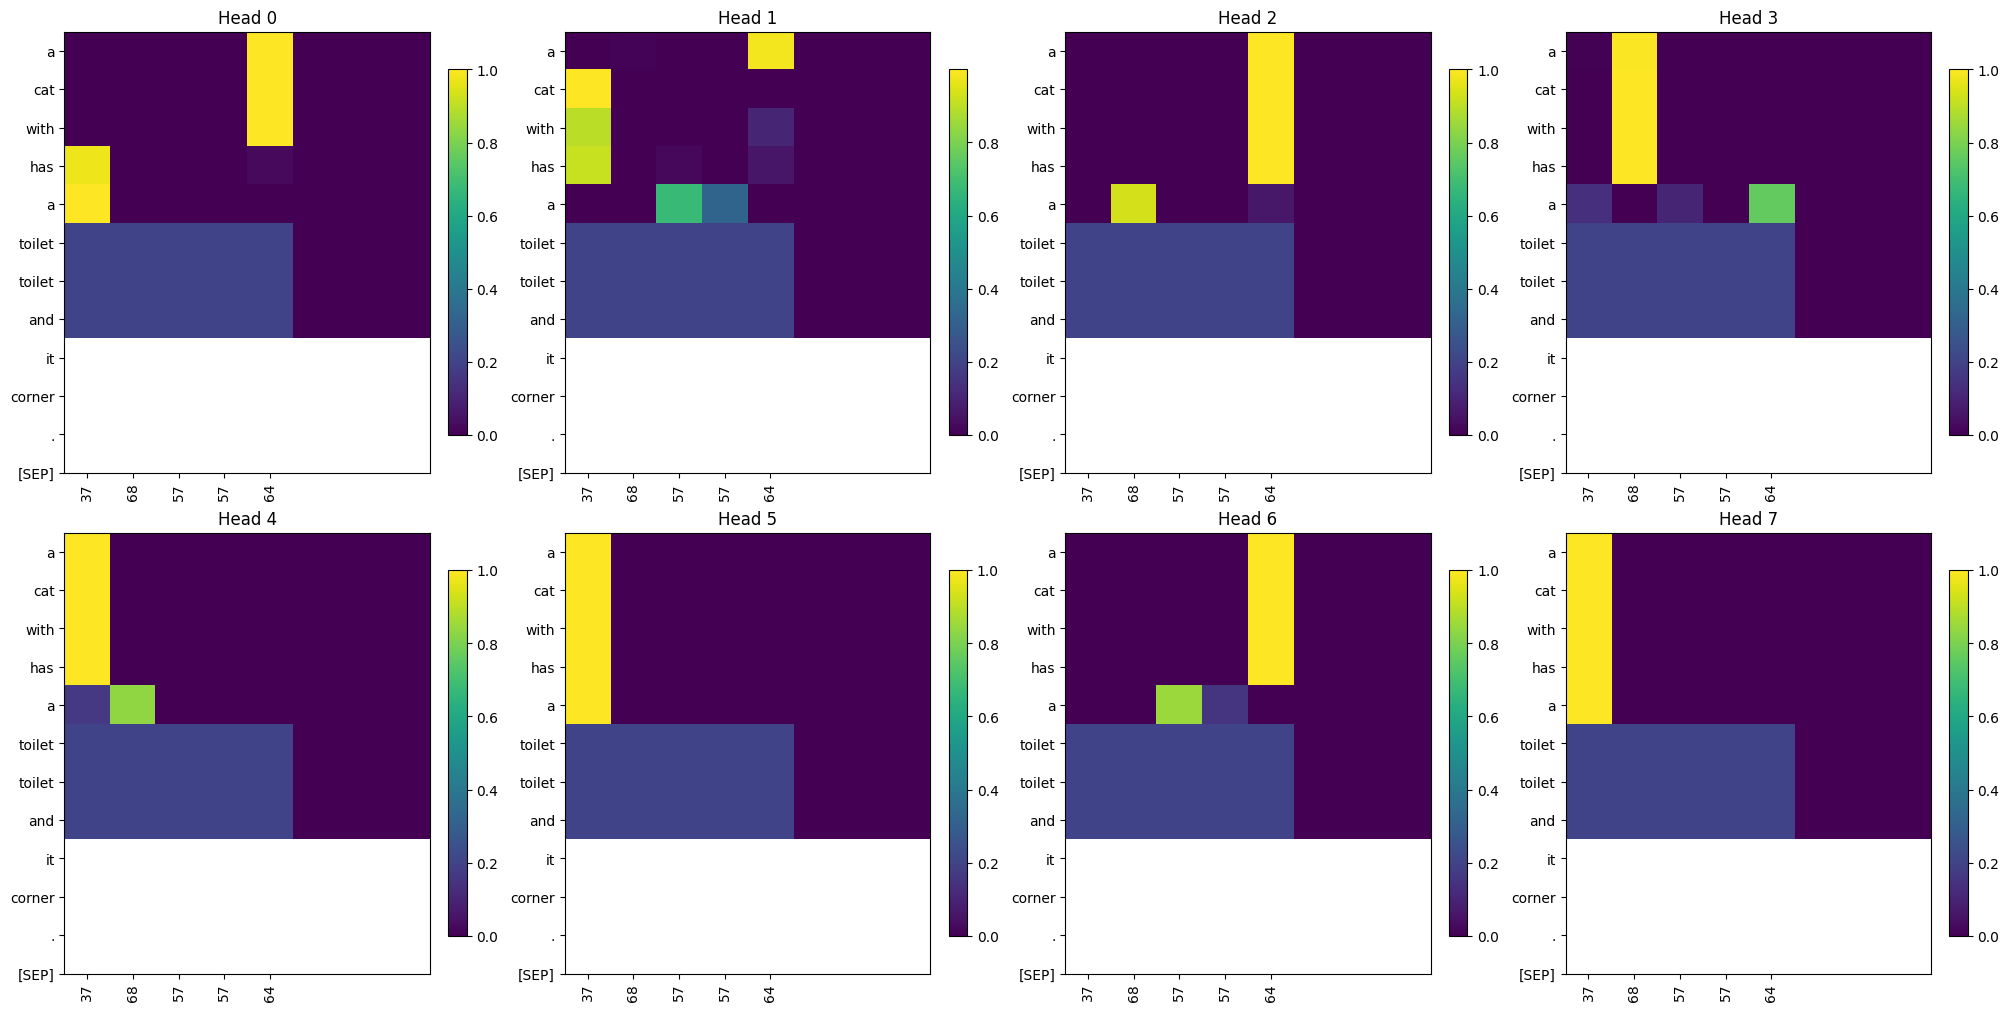

__


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Visualizing 8 attention heads
Attention shape: torch.Size([8, 8, 8])


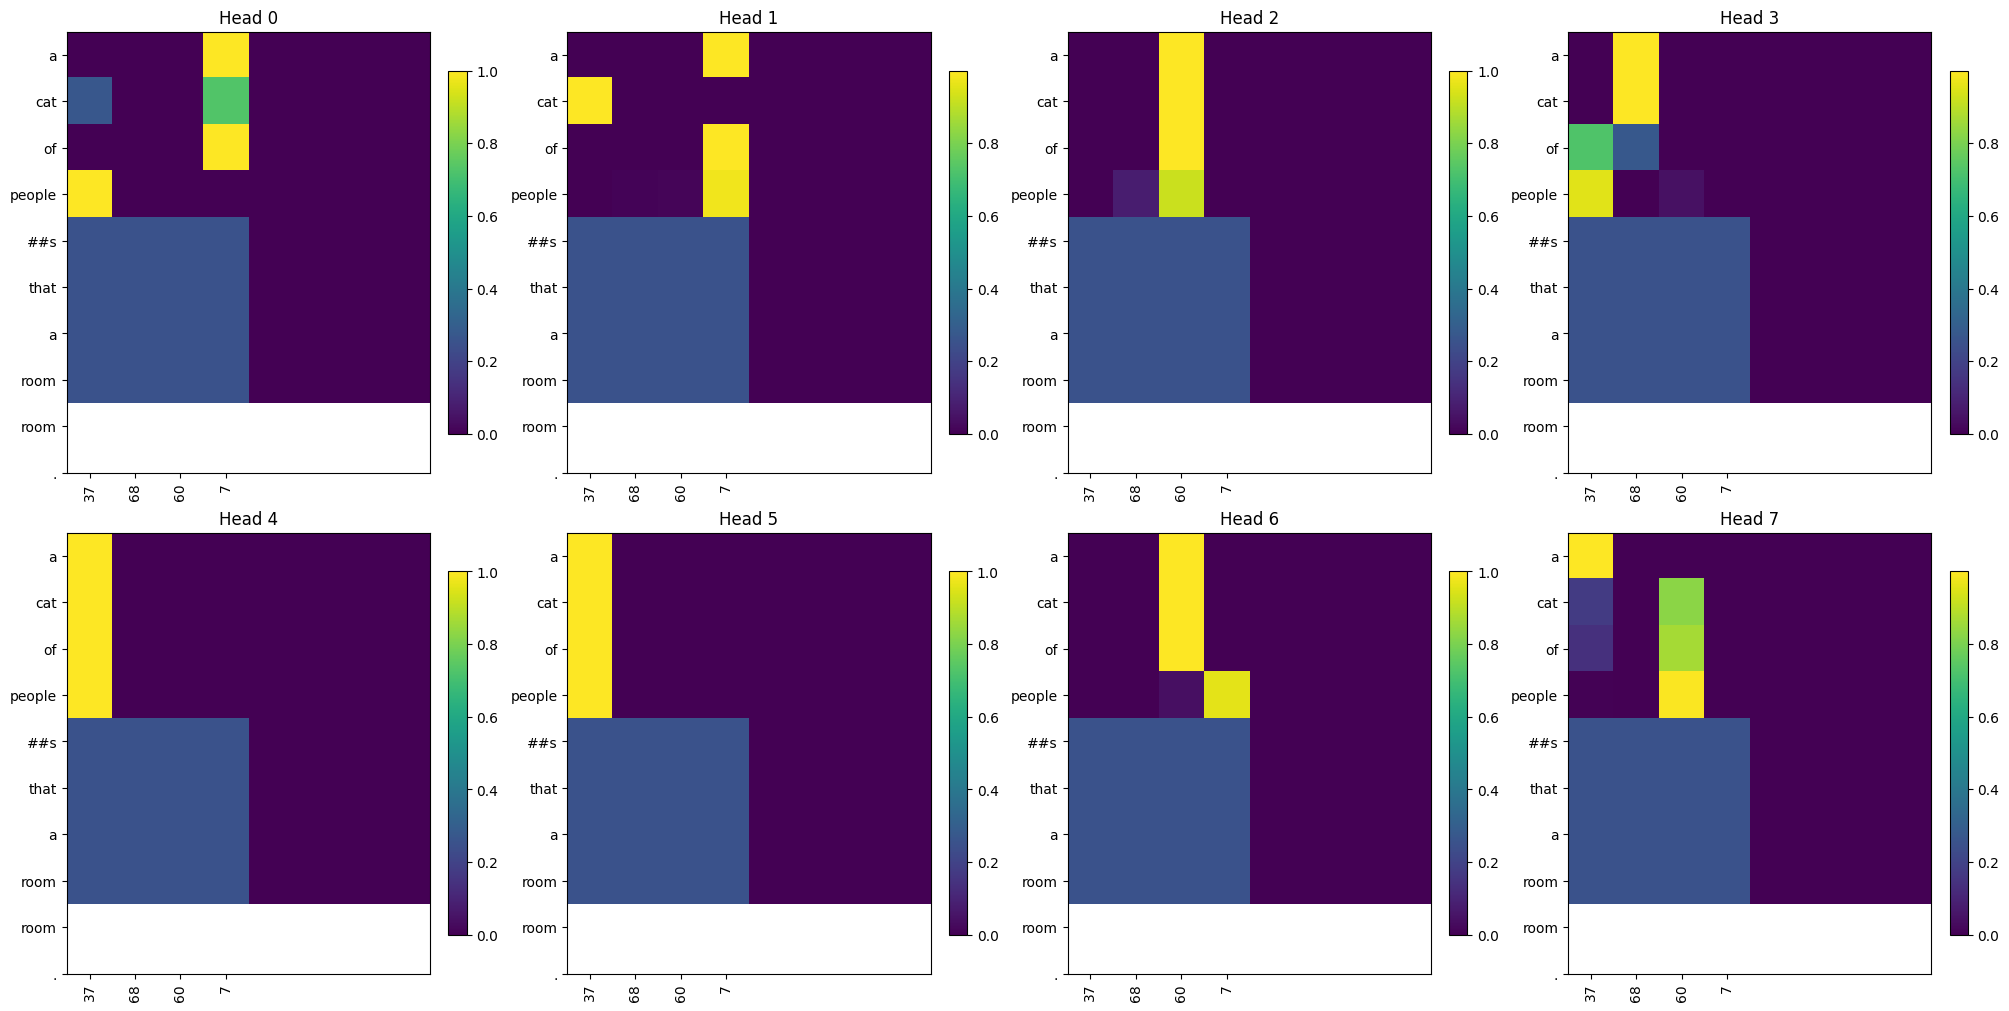

__


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Visualizing 8 attention heads
Attention shape: torch.Size([8, 8, 8])


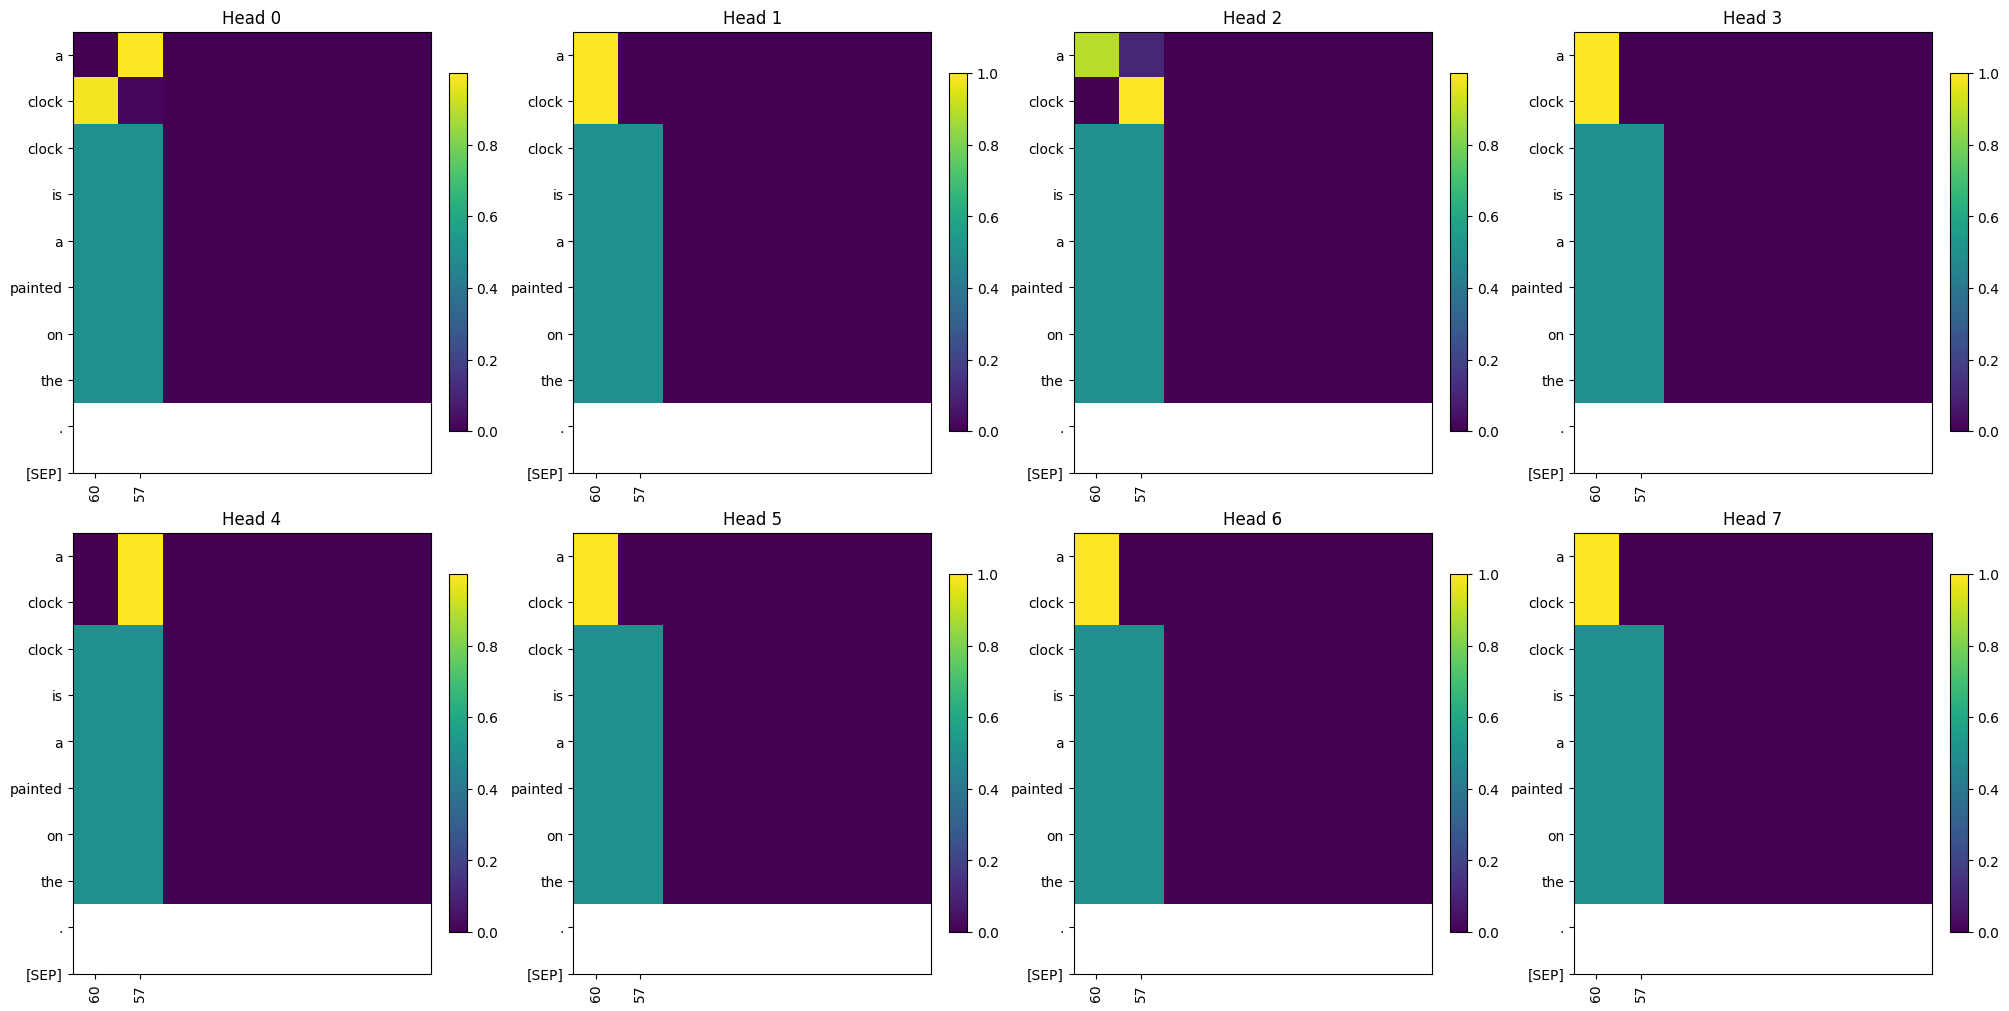

__


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Visualizing 8 attention heads
Attention shape: torch.Size([8, 8, 8])


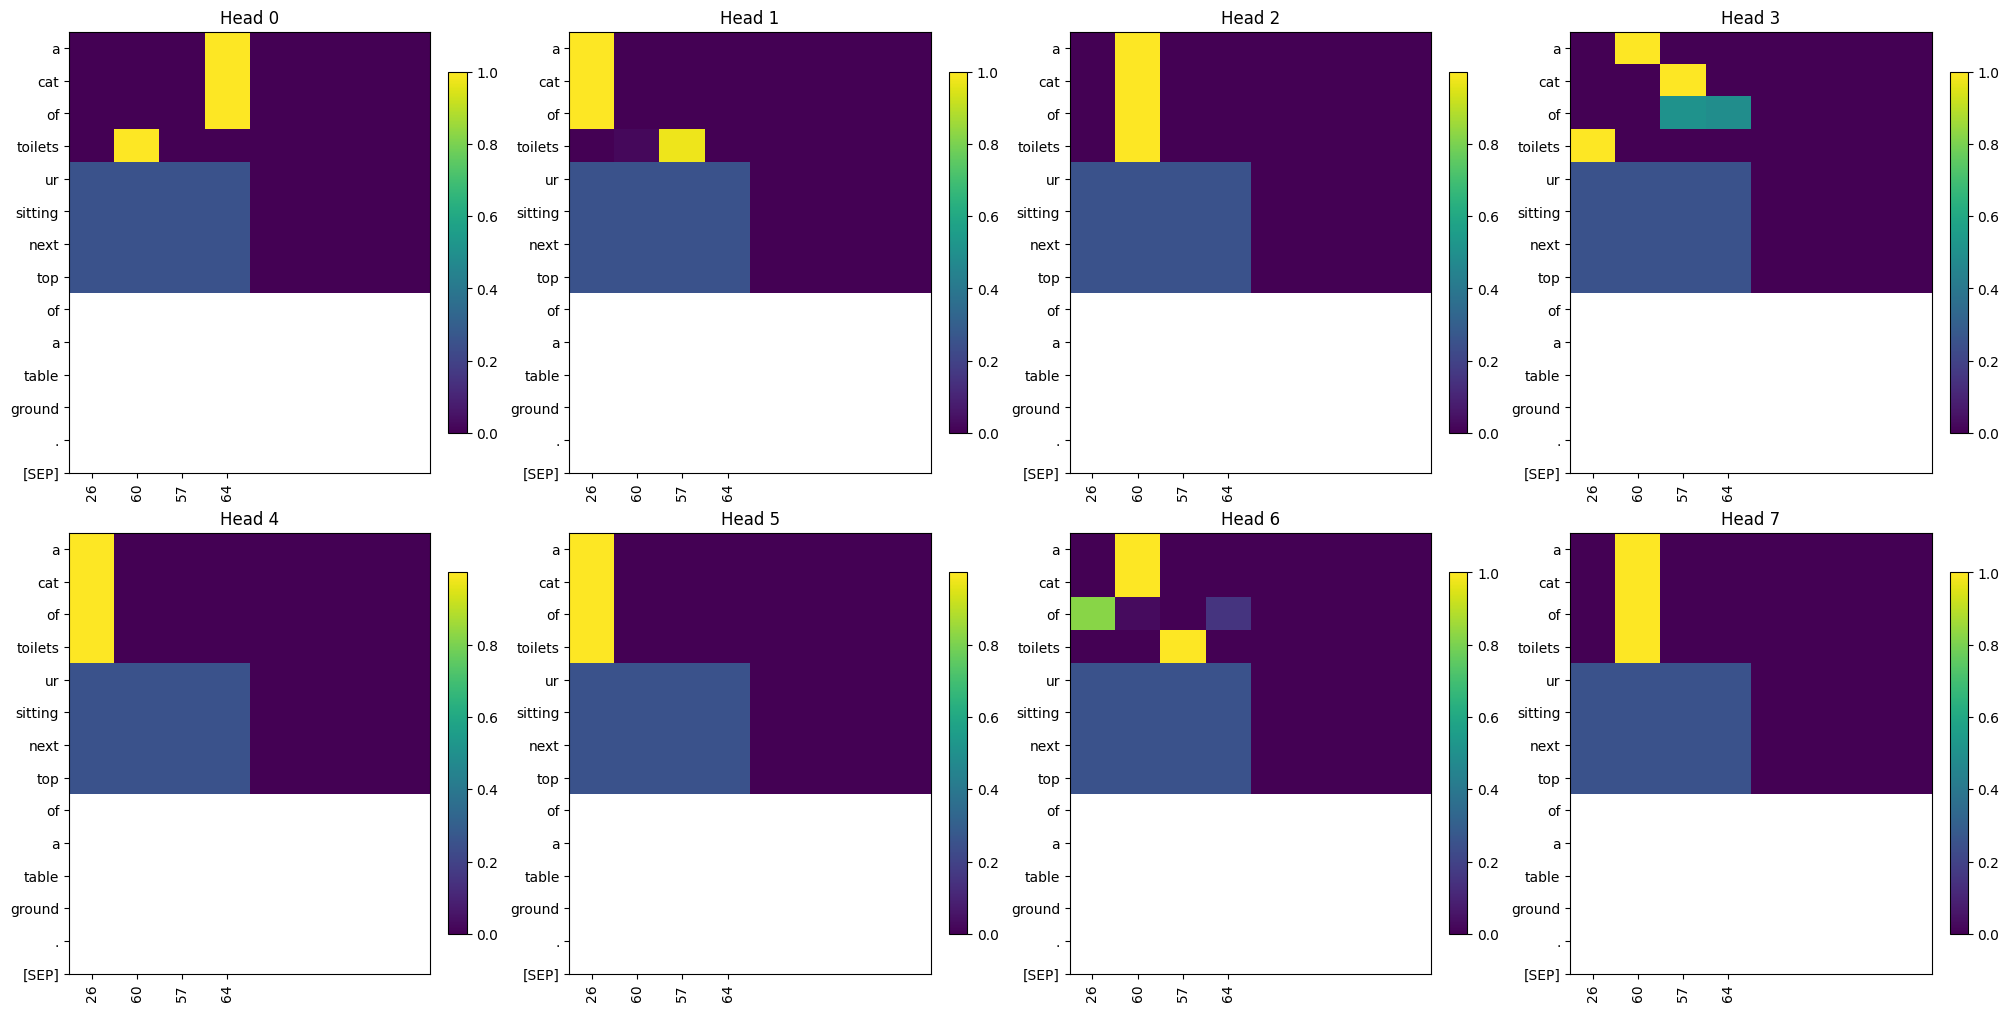

__


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Visualizing 8 attention heads
Attention shape: torch.Size([8, 8, 8])


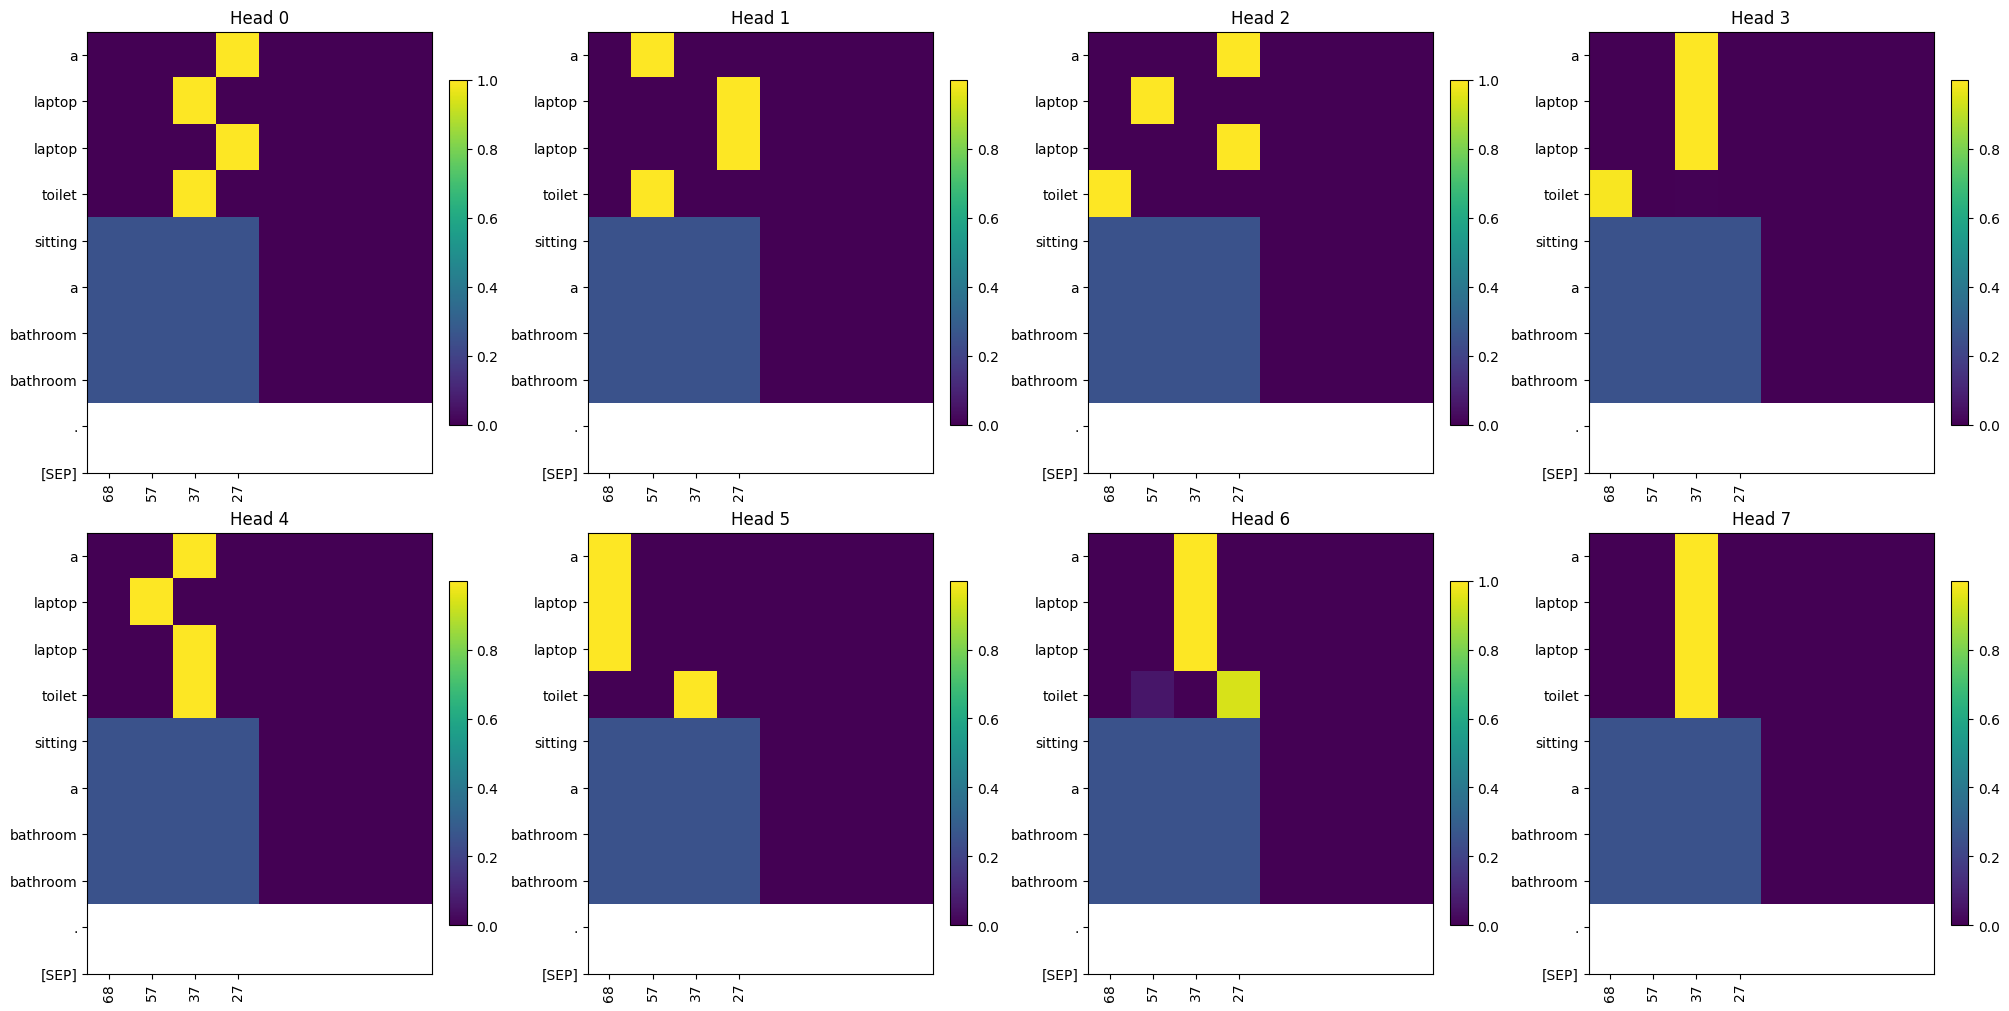

__


In [73]:
for i in range(10):
    self_attention(i)
    print('__')